## expxx

### reward 部分的绘制

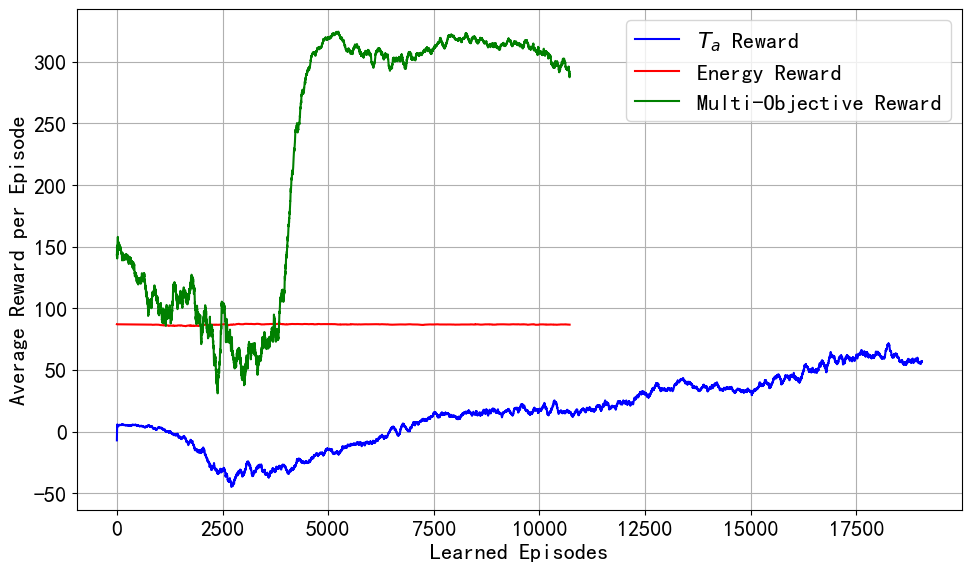

In [12]:
import os
import json
import matplotlib.pyplot as plt

# 设置全局字体大小
plt.rcParams['font.size'] = 16

plt.rcParams['font.sans-serif'] = ['SimHei']  # 设置中文字体
plt.rcParams['axes.unicode_minus'] = False  # 解决负号显示问题


# 统一读取数据

# DQN- Ta
Ta_dqn_ep_rew_mean = []
Ta_dqn_episodes = []
with open(os.path.join(rf"data\compare_data\250723 V1 Ta reward", "progress.json"), "r", encoding="utf-8") as f:
    for line in f: # 每一行读取
        if line.strip(): # 确保行不为空
            data = json.loads(line) # 单行的 data 部分
            if "rollout/ep_rew_mean" in data and "time/episodes" in data:
                Ta_dqn_ep_rew_mean.append(data["rollout/ep_rew_mean"])
                Ta_dqn_episodes.append(data["time/episodes"])
                
# DQN energy
energy_dqn_ep_rew_mean = []
energy_dqn_episodes = []
with open(os.path.join(rf"data\compare_data\250723 V1 energy reward", "progress.json"), "r", encoding="utf-8") as f:
    for line in f: # 每一行读取
        if line.strip(): # 确保行不为空
            data = json.loads(line) # 单行的 data 部分
            if "rollout/ep_rew_mean" in data and "time/episodes" in data:
                energy_dqn_ep_rew_mean.append(data["rollout/ep_rew_mean"])
                energy_dqn_episodes.append(data["time/episodes"])
            else:
                print("缺少数据")

# DQN multi obj
multi_obj_dqn_ep_rew_mean = []
multi_obj_dqn_episodes = []
with open(os.path.join(rf"data\compare_data\250724 V1 weight_three_obj_over", "progress.json"), "r", encoding="utf-8") as f:
    for line in f: # 每一行读取
        if line.strip(): # 确保行不为空
            data = json.loads(line) # 单行的 data 部分
            if "rollout/ep_rew_mean" in data and "time/episodes" in data:
                multi_obj_dqn_ep_rew_mean.append(data["rollout/ep_rew_mean"])
                multi_obj_dqn_episodes.append(data["time/episodes"])

# 绘制 Reward
plt.figure(figsize=(10, 6))

plt.plot(Ta_dqn_episodes, Ta_dqn_ep_rew_mean, label="$T_a$ Reward", color='blue')
plt.plot(energy_dqn_episodes, energy_dqn_ep_rew_mean, label="Energy Reward", color='red')
plt.plot(multi_obj_dqn_episodes, multi_obj_dqn_ep_rew_mean, label="Multi-Objective Reward", color='green')

plt.xlabel("Learned Episodes")
plt.ylabel("Average Reward per Episode")
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()


### 训练结果绘制

In [ ]:
# 成功结果的示意(在线读取版本)
import sys
import os

from stable_baselines3 import DQN

# 将 src 目录添加到模块搜索路径
sys.path.append(os.path.abspath('src'))

# 导入 IEMEnv 类
from src.envs.iseec_lx_v4_mdp_plot import IEMEnv
import pandas as pd
import datetime
import numpy as np
from matplotlib.gridspec import GridSpec
import os
import json
import matplotlib.pyplot as plt

# 指定对应的保存数据
def save_future_data_analysis(total_action=None, env=None, total_state=None, total_reward=None, total_done=None):
    """

    保存数据到 csv 文件，方便以后变成高纬度数据进行保存
    """
    # 保存当前信息到 csv 文件
    # 创建DataFrame来存储数据
    data = {
        "year": [],
        "T_a": [],
        "C_a": [],
        "C_o": [],
        "C_od": [],
        "T_o": [],
        "E21": [],
        "E22": [],
        "E23": [],
        "E24": [],
        "E12": [],
        "action_0": [],
        "reward": [],
        "done": [],
    }

    # 遍历所有步骤收集数据
    for step in range(len(total_action)):
        # 添加年份
        data["year"].append(env.control_start_year + step)

        # 添加状态值
        state = total_state[step]
        data["T_a"].append(state[0])
        data["C_a"].append(state[1])
        data["C_o"].append(state[2])
        data["C_od"].append(state[3])
        data["T_o"].append(state[4])
        data["E21"].append(state[5])
        data["E22"].append(state[6])
        data["E23"].append(state[7])
        data["E24"].append(state[8])
        data["E12"].append(state[9])

        # 添加动作
        action = total_action[step]
        data["action_0"].append(action)

        # 添加奖励和完成状态
        data["reward"].append(total_reward[step])
        data["done"].append(total_done[step])

    # 创建DataFrame并保存到CSV
    df = pd.DataFrame(data)

    # 指定文件夹位置
    main_directory = "supplyment"
    # sub_directory = custom_reward_type
    sub_directory = os.path.join(main_directory, "save_future_data")
    os.makedirs(sub_directory, exist_ok=True)  # 自动创建最下面的
    # 获取当前时间并格式化
    current_time = datetime.datetime.now().strftime("%Y%m%d_%H%M%S")
    # 将文件保存到 output 文件夹，使用时间戳命名
    filename = f"episode_1_results_{current_time}.csv"
    file_path = os.path.join(sub_directory, filename)
    # csv 保存
    df.to_csv(file_path, index=False)
    
    print(f"已保存数据到 {file_path}")

def plot_state_analysis(total_action=None, total_state=None, env=None):
    """
    画出状态的分布图，包含 NSM 和 SSM 的 4 张图
    """
    time_start = 2017
    time_end = time_start + len(total_state)
    time_range = range(time_start, time_end)
    
    # 环境数据转换为本地
    total_state = np.array(total_state)
    IAM_CO2concentration = env.IAM_CO2concentration
    IAM_Temperature = env.IAM_Temperature
    rho_a = env.rho_a
    T_a = total_state[:, 0] # total_state 是 83*10
    C_a = total_state[:, 1]
    C_o = total_state[:, 2]
    C_od = total_state[:, 3]
    T_o = total_state[:, 4]
    E21 = total_state[:, 5]
    E22 = total_state[:, 6]
    E23 = total_state[:, 7]
    E24 = total_state[:, 8]
    E12 = total_state[:, 9]
    E11 = (
            env.energy_MYadjusted18502100_total_plus_B3B_plus_ACE3[-1]
            - E12
            - E21
            - E22
            - E23
            - E24
        )  # in this model set up, E terms are absoluate values
    energy_MYbaseline18502100_FF = env.energy_MYbaseline18502100_FF
    energy_MYbaseline20172100_FF = energy_MYbaseline18502100_FF[-len(time_range):]

    fig = plt.figure(figsize=(12, 8))
    
    fig.suptitle('the data ISEEC Model simulated in the future period') 

    gs = GridSpec(2, 2, figure=fig, wspace=0.3, hspace=0.3) # 选择格子对应
    
    # 子图1：占据第1行第1列的网格
    ax1 = fig.add_subplot(gs[0, 0])
    ax1.plot(time_range, C_a * rho_a, label='Simulated', color='blue') # 设计单位换算的地方
    ax1.plot(IAM_CO2concentration.iloc[2-2,4:].astype('float') , label = 'IAMs',linestyle='dotted', marker='',color = 'blue') # 需要增加 x 轴
    ax1.plot(IAM_CO2concentration.iloc[3-2,4:].astype('float') , linestyle='dotted', marker='',color = 'blue')
    ax1.plot(IAM_CO2concentration.iloc[4-2,4:].astype('float') , linestyle='dotted', marker='',color = 'blue')
    ax1.plot(IAM_CO2concentration.iloc[5-2,4:].astype('float') , linestyle='dotted', marker='',color = 'blue')
    ax1.set_xlim((2016, 2100))
    ax1.set_ylabel("CO2 concentration (ppm)")
    ax1.legend(loc='upper right', fontsize='small')  # 调整图例位置和字体大小
    ax1.tick_params(axis='x', labelsize=8)  # 调整刻度标签大小
    ax1.tick_params(axis='y', labelsize=8)
    
    # 子图2：占据第1行第2列的网格
    ax2 = fig.add_subplot(gs[0, 1])
    ax2.plot(time_range, T_a, label='ISEEC Simulated', color='black')
    ax2.plot(IAM_Temperature.iloc[2-2,4:].astype('float') , label = 'IAMs',linestyle='dotted', marker='',color = 'blue')
    ax2.plot(IAM_Temperature.iloc[3-2,4:].astype('float') ,linestyle='dotted', marker='',color = 'blue')
    ax2.plot(IAM_Temperature.iloc[4-2,4:].astype('float') , linestyle='dotted', marker='',color = 'blue')
    ax2.plot(IAM_Temperature.iloc[5-2,4:].astype('float') , linestyle='dotted', marker='',color = 'blue')
    ax2.set_xlim((2016, 2100))
    ax2.set_ylabel('Temperature (K)')
    ax2.legend()  # 添加 legend
    
    # SSM 变量绘制
    # 子图3：占据第2行第1列的网格
    ax3 = fig.add_subplot(gs[1, 0])
    ax3.plot(time_range, E11, label='E11')  # 设计单位换算的地方
    # ax3.plot(energy_MYbaseline20172100_FF + 15, linestyle='-', marker='.', color='black',
    #          label='E11_GCB')  # Global_Carbon_Budget_2018v1.0.xlsx
    ax3.set_xlim((2016, 2100))
    ax3.set_ylabel("EJ/yr")
    ax3.legend(loc='upper right', fontsize='small')
    ax3.tick_params(axis='x', labelsize=8)
    ax3.tick_params(axis='y', labelsize=8)
    
    # 子图4：占据第2行第2列的网格
    ax4 = fig.add_subplot(gs[1, 1])
    ax4.plot(time_range, E21, color='black', label='E21')
    ax4.set_xlim((2016, 2100))
    ax4.set_ylabel("EJ/yr")
    ax4.legend(loc='upper right', fontsize='small')
    ax4.tick_params(axis='x', labelsize=8)
    ax4.tick_params(axis='y', labelsize=8)

    # 调整布局以防止标签重叠
    plt.tight_layout()
    
    # 显示绘图
    plt.show()
        
def plot_all_state_analysis(total_action=None, total_state=None):
    """
    画出所有状态的分布图都在一张图里面，参照 copan的画法
    """
    time_start = 2017
    time_end = time_start + len(total_state)
    time_range = range(time_start, time_end)
    
    total_state = np.array(total_state)
    
    # 左侧是有单位的，右侧是缩放的变量值
    T_a = total_state[:, 0] # total_state 是 83*10
    C_a = total_state[:, 1]
    C_o = total_state[:, 2]
    C_od = total_state[:, 3]
    T_o = total_state[:, 4]
    E21 = total_state[:, 5]
    E22 = total_state[:, 6]
    E23 = total_state[:, 7]
    E24 = total_state[:, 8]
    E12 = total_state[:, 9]

    # 单位不一样的需要归一化
    T_a_normalized = (T_a - 0) / (4 - 0)
    C_a_normalized = (C_a - 600 ) / (1319 - 600)
    C_o_normalized = (C_o - 100 ) / (200 - 100)
    C_od_normalized = (C_od - 1000) / (1900 - 1000)
    T_o_normalized = (T_o - 0) / (2.6 - 0)
    
    fig, ax = plt.subplots(figsize=(10, 6))
    ax2 = ax.twinx()  # 创建副y轴
    
    # 绘制10维变量，
    # SSM 的5维变量用很粗的线绘制
    ax.plot(time_range, E21, label='E21', linewidth=2, color="blue",)
    ax.plot(time_range, E22, label='E22', linewidth=2,color="green",)
    ax.plot(time_range, E23, label='E23', linewidth=2,color="black",)
    ax.plot(time_range, E24, label='E24', linewidth=2, color="pink",)
    ax.plot(time_range, E12, label='E12', linewidth=2, color="red",)
    
    ax.set_ylabel('E21,E22,E23,E24,E12 [EJ]')
    # 其他变量用正常绘制
    ax2.plot(time_range, T_a_normalized, label='T_a_normalized', linestyle='--')
    ax2.plot(time_range, C_a_normalized, label='C_a_normalized', linestyle='--')
    ax2.plot(time_range, C_o_normalized, label='C_o_normalized', linestyle='--')
    ax2.plot(time_range, C_od_normalized, label='C_od_normalized', linestyle='--')
    ax2.plot(time_range, T_o_normalized, label='T_o_normalized', linestyle='--')

    ax2.set_ylabel('Rel. shares [%] / Scaled variables: x→x-min/(max-min)')
    
    # 合并图例
    lines, labels = ax.get_legend_handles_labels()
    lines2, labels2 = ax2.get_legend_handles_labels()
    ax2.legend(lines + lines2, labels + labels2, loc='center left', bbox_to_anchor=(1.15, 0.5), fancybox=True, ncol=1)

    # 设置 x 轴从 2017 年开始
    ax.set_xlabel('t [years]')
    ax.set_xlim(time_start, time_end - 1)
    ax.set_xticks(np.arange(time_start, time_end, 10))  # 每10年一个刻度

def plot_action_analysis(total_action=None, total_state=None, env=None):
    """
    画出动作的分布图，包含了详细的各部分子动作部分，里面可以参照相关的对比细节部分
    
    绘制因为 action 改变的最直接的子state变化, 体现是宏观动作对于细节模型的变化部分
    
    时间范围：2017-2100（这段时间结果明显）
        
    因为 action 改变的子state 包括：
    1. Action-社会响应实践时间 (taoR21·/taoP21/taoR22/taoP22)
    2. Action-技术扩散时间 (taoDV21/taoDF21/taoDV22/taoDF22)
    3. Action-大幅增加可再生能源技术的启动投资（eta21/eta22 区分开）
    4. Action-大幅增加大气碳提取技术的启动投资 ACE (etaACE1/etaACE2/etaACE3)
    
    为了绘制清楚，只区分 21 和 22 部分
    
    为了对比不同情景，绘制结果需要保存到本地，方面对比绘制
    """
    time_start = 2017
    time_end = time_start + len(total_state)
    time_range = range(time_start, time_end)
    
    total_action = np.array(total_action)
    
    fig = plt.figure(figsize=(16, 18))
    gs = GridSpec(3, 2, figure=fig, height_ratios=[2, 1, 1], hspace=0.4, wspace=0.3)
    
    # 大图（跨2列）- 用散点图
    ax_big = fig.add_subplot(gs[0, :])
    ax_big.scatter(time_range, total_action, label='Macro action over time', color='tab:blue', s=30)
    ax_big.set_title('Action choice')
    ax_big.set_xlabel('t [years]', fontsize=14)
    ax_big.set_ylabel('Chosen Action', fontsize=14)
    # ax_big.legend()
    # ax_big.grid(True)
    
    # # 添加动作说明
    # action_labels = [
    #     " 2: renewable energy",
    #     " 4: Speed the progress of ACE",
    #     " 6: renewable energy + ACE",
    #     "12: ACE + renewable Energy",
    #     "15: all actions",
    # ]

    # # 在大图右侧添加文本说明
    # ax_big.text(
    #     1.02, 0.5, "\n".join(action_labels),
    #     transform=ax_big.transAxes,
    #     fontsize=12,
    #     va='center',
    #     bbox=dict(facecolor='white', edgecolor='black', boxstyle='round,pad=0.5')
    # )
     
    # 长度转换，detailed actions 都是 251 长度，需要转换为 time_range 一样 83
    taoR21 = env.taoR21[-len(time_range):]
    taoP21 = env.taoP21[-len(time_range):]
    taoDV21 = env.taoDV21[-len(time_range):]
    taoDF21 = env.taoDF21[-len(time_range):]
    tao21 = env.tao21[-len(time_range):]
    
    taoR22 = env.taoR22[-len(time_range):]
    taoP22 = env.taoP22[-len(time_range):]
    taoDV22 = env.taoDV22[-len(time_range):]
    taoDF22 = env.taoDF22[-len(time_range):]
    tao22 = env.tao22[-len(time_range):]
    
    eta21 = env.eta21[-len(time_range):]
    eta22 = env.eta22[-len(time_range):]
    
    CO2emission_ACE1 = env.CO2emission_ACE1[-len(time_range):]
    CO2emission_ACE2 = env.CO2emission_ACE2[-len(time_range):]
    CO2emission_ACE3 = env.CO2emission_ACE3[-len(time_range):]

    # 第一个子图 - 社会响应实践时间
    ax1 = fig.add_subplot(gs[1, 0])
    ax1.plot(time_range, taoR21, 'blue', label='tau_R21')
    ax1.plot(time_range, taoP21, 'black', label='tau_P21')
    ax1.plot(time_range, taoDV21, 'green', label='tau_DV21')
    ax1.plot(time_range, taoDF21, 'red', label='tau_DF21')
    ax1.plot(time_range, tao21, 'purple', label='tau21 total')
    ax1.set_xlabel('Year', fontsize=14)
    ax1.set_ylabel('Response time of technology E21', fontsize=12)
    ax1.legend()
    ax1.grid(True)
    ax1.set_xlim(min(time_range), max(time_range))
    ax1.xaxis.set_major_locator(plt.MaxNLocator(6))
    for spine in ax1.spines.values():
        spine.set_visible(True)

    # 子图2
    ax2 = fig.add_subplot(gs[1, 1])
    ax2.plot(time_range, taoR22, 'blue', label='tau_R22')
    ax2.plot(time_range, taoP22, 'black', label='tau_P22')
    ax2.plot(time_range, taoDV22, 'green', label='tau_DV22')
    ax2.plot(time_range, taoDF22, 'red', label='tau_DF22')
    ax2.plot(time_range, tao22, 'purple', label='tau22 total')
    ax2.set_xlabel('Year', fontsize=14)
    ax2.set_ylabel('Response time of technology E22', fontsize=12)
    ax2.legend()
    ax2.grid(True)
    ax2.set_xlim(min(time_range), max(time_range))
    ax2.xaxis.set_major_locator(plt.MaxNLocator(6))
    for spine in ax2.spines.values():
        spine.set_visible(True)

    # 子图3
    ax3 = fig.add_subplot(gs[2, 0])
    ax3.plot(time_range, eta21, 'blue', label='eta21')
    ax3.plot(time_range, eta22, 'black', label='eta22')
    ax3.set_xlabel('Year', fontsize=14)
    ax3.set_ylabel('Investment of technology E21/E22', fontsize=12)
    ax3.legend()
    ax3.grid(True)
    ax3.set_xlim(min(time_range), max(time_range))
    ax3.xaxis.set_major_locator(plt.MaxNLocator(6))
    for spine in ax3.spines.values():
        spine.set_visible(True)

    # 子图4
    ax4 = fig.add_subplot(gs[2, 1])
    ax4.plot(time_range, [x*44/12 for x in CO2emission_ACE1], label='ACE1', color='blue')
    ax4.plot(time_range, [x*44/12 for x in CO2emission_ACE2], label='ACE2', color='blue', linestyle='dashed')
    ax4.plot(time_range, [x*44/12 for x in CO2emission_ACE3], label='ACE3', color='green')
    ax4.set_xlabel('Year', fontsize=14)
    ax4.set_ylabel('Extraction (Gt CO2/yr)', fontsize=12)
    ax4.legend()
    ax4.grid(True)
    ax4.set_xlim(min(time_range), max(time_range))
    ax4.xaxis.set_major_locator(plt.MaxNLocator(6))
    for spine in ax4.spines.values():
        spine.set_visible(True)

    plt.tight_layout(rect=[0, 0, 1, 0.96])
    plt.show()

def plot_action_3D_analysis():
    """绘制3D的轨迹分析图过程"""
    # 详见具体的 csv
    pass

def plot_state_action_analysis():
    """
    画出状态和动作的分布图
    """
    
def plot_state_action_reward_analysis(index=None, total_state=None, total_action=None, total_reward=None):
    """
    画出状态、动作、奖励的分布图
    """
    
    time = index + 2017
    
    # 3 图版本
    fig, ax = plt.subplots(figsize=(10, 6))
    
    # 4 图版本

    # TODO: 实现状态和动作的分布图
    pass


# 加载对应环境
# env = IEMEnv(reward_type="multi_objective_single_T_a_exp8")

# 加载对应模型
model = DQN.load(f"./model/iseec_lx_v4_mdp_plot_DQN_multi_objective_single_T_a_exp8_700000_default", env=env)

max_steps = 300

for episode in range(1):  

    ##################################
    # 记录所需数组：每次 episode 重置
    total_action = []
    total_state = []
    total_reward = []
    total_done = []
    ##################################

    episode_reward = 0

    obs, _  = env.reset(use_random_reset=False, seed=42)  # 重置环境，获得初始状态


    for i in range(max_steps):

        action, _ = model.predict(obs, deterministic=True)
        
        obs, reward, done, _, info = env.step(action)  # 获得的应该是下一次的 state

        episode_reward += reward
        ##################################
        
        if done:
            print(f"Episode {episode} finished at step {i}")
            plot_state_action_analysis()
            break
        
        ############ 添加转换的部分 #########
        action_number, action_name = IEMEnv.action2number_env(action)
        
        total_action.append(action_number)
        total_state.append(obs)
        total_reward.append(reward)
        total_done.append(done)

        # # 打印每次运行结果
        # print(i + env.model_init_year)
        # print(f"当前奖励: {reward}")
        # print(f"累计奖励: {episode_reward}")
        # print(f"额外信息: {info}")
        
    print("---------------------------------------")
    print(f"Episode {episode} finished at step {i}")

    # 每次 episode 结束时保存数据
    # save_future_data_analysis(total_action=total_action, env=env,total_state=total_state, total_reward=total_reward, total_done=total_done)
    plot_state_analysis(total_action=total_action, total_state=total_state, env=env)
    plot_all_state_analysis(total_action=total_action, total_state=total_state)
    plot_action_analysis(total_action=total_action, total_state=total_state, env=env)



[1850 1851 1852 1853 1854 1855 1856 1857 1858 1859 1860 1861 1862 1863
 1864 1865 1866 1867 1868 1869 1870 1871 1872 1873 1874 1875 1876 1877
 1878 1879 1880 1881 1882 1883 1884 1885 1886 1887 1888 1889 1890 1891
 1892 1893 1894 1895 1896 1897 1898 1899 1900 1901 1902 1903 1904 1905
 1906 1907 1908 1909 1910 1911 1912 1913 1914 1915 1916 1917 1918 1919
 1920 1921 1922 1923 1924 1925 1926 1927 1928 1929 1930 1931 1932 1933
 1934 1935 1936 1937 1938 1939 1940 1941 1942 1943 1944 1945 1946 1947
 1948 1949 1950 1951 1952 1953 1954 1955 1956 1957 1958 1959 1960 1961
 1962 1963 1964 1965 1966 1967 1968 1969 1970 1971 1972 1973 1974 1975
 1976 1977 1978 1979 1980 1981 1982 1983 1984 1985 1986 1987 1988 1989
 1990 1991 1992 1993 1994 1995 1996 1997 1998 1999 2000 2001 2002 2003
 2004 2005 2006 2007 2008 2009 2010 2011 2012 2013 2014 2015 2016 2017
 2018 2019 2020 2021 2022 2023 2024 2025 2026 2027 2028 2029 2030 2031
 2032 2033 2034 2035 2036 2037 2038 2039 2040 2041 2042 2043 2044 2045
 2046 

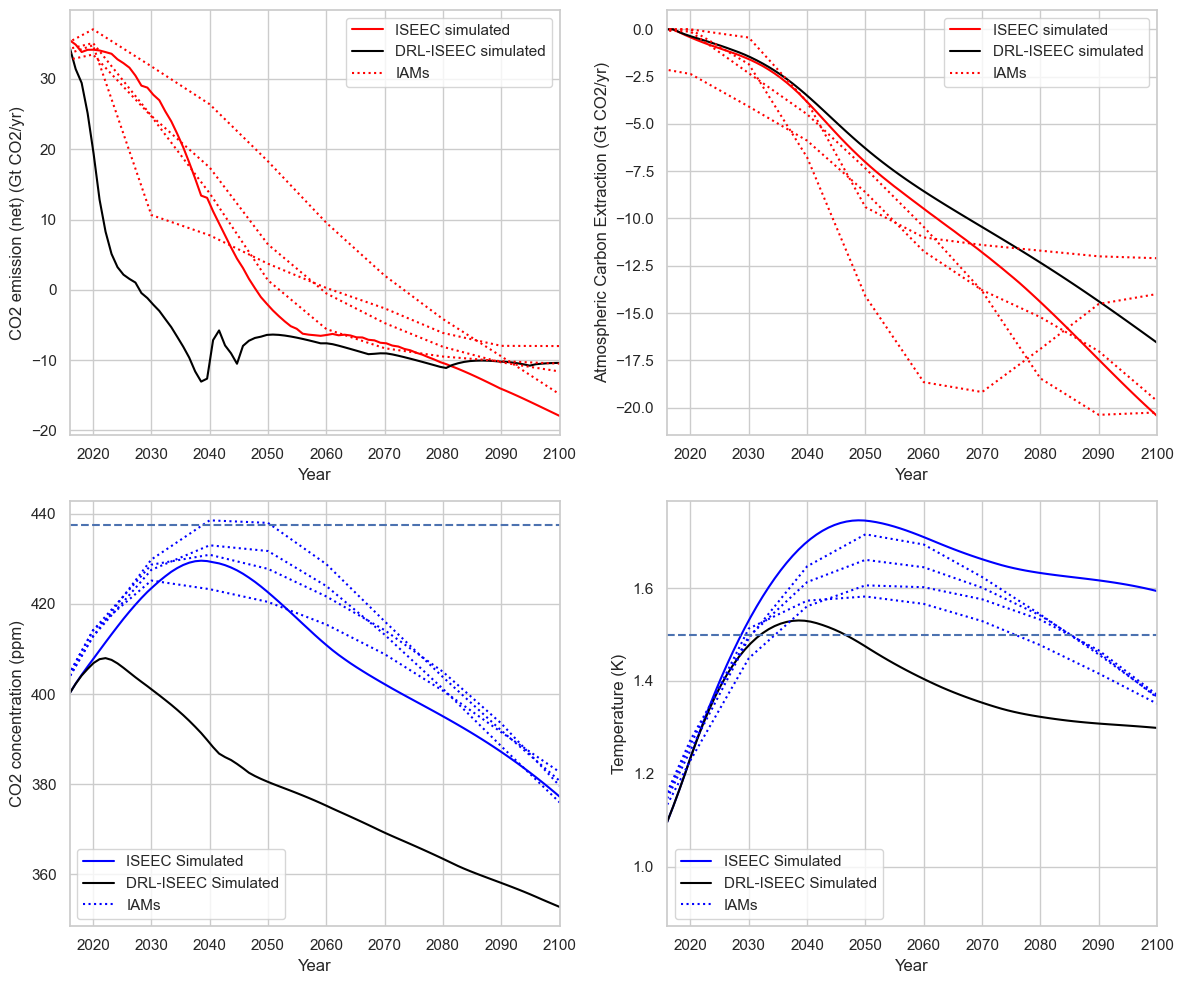

In [44]:
# 绘制 state(share of renewable energy/co2 net emission co2 concentration/temperature)
# 读取 data 里面 compare_data 里面的相关数据进行比较绘制

import numpy as np
import pandas as pd
import sys
import os
from src.envs.iseec_lx_v5_pomdp_without_masking_all_actions import IEMEnv
sys.path.append(os.path.abspath('src'))
import matplotlib.pyplot as plt

custom_reward_type = "weight_three_obj_over"
env = IEMEnv(reward_type=custom_reward_type)

# 读取第一维度数据:iseec-default
df_83_type1 = pd.read_excel(rf"data\compare_data\250723 v1_default_action13\episode_0_results_20250724_202537.xlsx")
df_251_type1 = pd.read_excel(rf"data\compare_data\250723 v1_default_action13\iseec_ssp5_MIT_data_diy_weight_three_obj_over_fixed_action_13.xlsx")

# 读取第二维度数据 drl-iseec-DQN-iseec_lx_v5_ste_without_masking_DQN_weight_three_obj_over_900000_default（管控温度目前最合理的数值）
df_83_type2 = pd.read_excel(rf"data\compare_data\250724 V1 weight_three_obj_over\episode_0_results_20250724_201830.xlsx")
df_251_type2 = pd.read_excel(rf"data\compare_data\250724 V1 weight_three_obj_over\iseec_ssp5_MIT_data_diy_weight_three_obj_over_sever_trained.xlsx")

years = np.linspace(2016, 2100, 83)

# states_type1 = np.array(total_state_type1)
T_a_type1 = df_83_type1['T_a']
C_a_type1 = df_83_type1['C_a']

E21_type1 = df_83_type1['E21']
E22_type1 = df_83_type1['E22']
E23_type1 = df_83_type1['E23']
E24_type1 = df_83_type1['E24']
E12_type1 = df_83_type1['E12']

energy_MYadjusted18502100_total_plus_B3B_plus_ACE3_type1 = df_251_type1['energy_MYadjusted18502100_total_plus_B3B_plus_ACE3']
energy_MYbaseline18502100_total_formulated_type1 = df_251_type1['energy_MYbaseline18502100_total_formulated']

E11_type1 = (
    energy_MYadjusted18502100_total_plus_B3B_plus_ACE3_type1[-83:]
    - E21_type1
    - E22_type1
    - E23_type1
    - E24_type1
    - E12_type1
)

CO2emission_actualFF_type1 = df_251_type1['CO2emission_actualFF']
CO2emission_ACE1_type1 = df_251_type1['CO2emission_ACE1']
CO2emission_ACE2_type1 = df_251_type1['CO2emission_ACE2']
CO2emission_ACE3_type1 = df_251_type1['CO2emission_ACE3']
ratio_net_over_gross_type1 = df_251_type1['ratio_net_over_gross']

T_a_type2 = df_83_type2['T_a']
C_a_type2 = df_83_type2['C_a']

E21_type2 = df_83_type2['E21']
E22_type2 = df_83_type2['E22']
E23_type2 = df_83_type2['E23']
E24_type2 = df_83_type2['E24']
E12_type2 = df_83_type2['E12']

energy_MYadjusted18502100_total_plus_B3B_plus_ACE3_type2 = df_251_type2['energy_MYadjusted18502100_total_plus_B3B_plus_ACE3']
energy_MYbaseline18502100_total_formulated_type2 = df_251_type2['energy_MYbaseline18502100_total_formulated']

E11_type2 = (
    energy_MYadjusted18502100_total_plus_B3B_plus_ACE3_type2[-83:]
    - E21_type2
    - E22_type2
    - E23_type2
    - E24_type2
    - E12_type2
)

CO2emission_actualFF_type2 = df_251_type2['CO2emission_actualFF']
CO2emission_ACE1_type2 = df_251_type2['CO2emission_ACE1']
CO2emission_ACE2_type2 = df_251_type2['CO2emission_ACE2']
CO2emission_ACE3_type2 = df_251_type2['CO2emission_ACE3']
ratio_net_over_gross_type2 = df_251_type2['ratio_net_over_gross']

################ 绘制 ##################
# 创建一个 figure
fig, axes = plt.subplots(2, 2, figsize=(12, 10))

# 统一的x轴
xlim = (2016, 2100)

# 子图1:
ax1 = axes[0, 0]
ax1.plot(years, [(x - b - c - d / e) * 44 / 12 for x, b, c, d, e in zip(CO2emission_actualFF_type1, CO2emission_ACE1_type1, CO2emission_ACE2_type1, CO2emission_ACE3_type1, ratio_net_over_gross_type1)][-83:], label='ISEEC simulated', color='red')
ax1.plot(years, [(x - b - c - d / e) * 44 / 12 for x, b, c, d, e in zip(CO2emission_actualFF_type2, CO2emission_ACE1_type2, CO2emission_ACE2_type2, CO2emission_ACE3_type2, ratio_net_over_gross_type2)][-83:], label='DRL-ISEEC simulated', color='black')

# 为IAMs曲线设置label，注意这里只在第一次绘制IAMs曲线时设置label，后续的IAMs曲线可以直接不设置label，
# 或者设置相同的label，因为它们通常代表同一组数据或模型变体
# 最好的做法是只在第一次 plot 时给 label，这样 legend 只有一个 "IAMs" 条目。
ax1.plot(env.IAM_CO2emission.iloc[10-2,4:].astype('float')/1e3-env.IAM_CO2emission.iloc[6-2,4:].astype('float')/1e3 , label = 'IAMs',linestyle='dotted', marker='',color = 'red') # 这一行已经有 label
ax1.plot(env.IAM_CO2emission.iloc[11-2,4:].astype('float')/1e3-env.IAM_CO2emission.iloc[7-2,4:].astype('float')/1e3, linestyle='dotted', marker='',color = 'red') # 无需重复设置 label，否则会创建多个相同的图例
ax1.plot(env.IAM_CO2emission.iloc[12-2,4:].astype('float')/1e3-env.IAM_CO2emission.iloc[8-2,4:].astype('float')/1e3 , linestyle='dotted', marker='',color = 'red')
ax1.plot(env.IAM_CO2emission.iloc[13-2,4:].astype('float')/1e3-env.IAM_CO2emission.iloc[9-2,4:].astype('float')/1e3 , linestyle='dotted', marker='',color = 'red')

ax1.legend() # 加上这行即可显示图例
ax1.set_ylabel('CO2 emission (net) (Gt CO2/yr)')
ax1.set_xlabel('Year')
ax1.set_xlim(xlim)


# 子图2: 
# ax2 = axes[0, 1]
# ax2.plot(years, energy_MYadjusted18502100_total_plus_B3B_plus_ACE3_type1[-83:], 
#         label='ISEEC simulated', color='blue')
# ax2.plot(years, energy_MYadjusted18502100_total_plus_B3B_plus_ACE3_type2[-83:], 
#         label='DRL-ISEEC simulated', color='black')
# ax2.plot(years, energy_MYbaseline18502100_total_formulated_type1[-83:], 
#         label='baseline', linestyle='dotted', color='red')
# ax2.set_ylabel('Total Energy (EJ)')
# ax2.set_xlabel('Year')
# ax2.set_xlim(xlim)
# # ax2.set_ylim(600, 1900)
# ax2.legend()
ax2 = axes[0, 1]
ax2.plot(years, [-(b+c+d/e)*44/12 for b,c,d,e in zip(CO2emission_ACE1_type1,CO2emission_ACE2_type1,CO2emission_ACE3_type1, ratio_net_over_gross_type1)][-83:],  label = 'ISEEC simulated',color = 'red',linestyle = 'solid')
ax2.plot(years, [-(b+c+d/e)*44/12 for b,c,d,e in zip(CO2emission_ACE1_type2,CO2emission_ACE2_type2,CO2emission_ACE3_type2, ratio_net_over_gross_type2)][-83:],  label = 'DRL-ISEEC simulated',color = 'black',linestyle = 'solid')
ax2.plot( -env.IAM_CO2emission.iloc[6-2,4:].astype('float')/1e3 , label = 'IAMs',linestyle='dotted', marker='',color = 'red')  # the 7th role is actual FF
ax2.plot( -env.IAM_CO2emission.iloc[7-2,4:].astype('float')/1e3 , linestyle='dotted', marker='',color = 'red')  # the 7th role is actual FF
ax2.plot( -env.IAM_CO2emission.iloc[8-2,4:].astype('float')/1e3 , linestyle='dotted', marker='',color = 'red')  # the 7th role is actual FF
ax2.plot( -env.IAM_CO2emission.iloc[9-2,4:].astype('float')/1e3 , linestyle='dotted', marker='',color = 'red')  # the 7th role is actual FF
ax2.legend()
ax2.set_ylabel('Atmospheric Carbon Extraction (Gt CO2/yr)')
ax2.set_xlabel('Year')
ax2.set_xlim(xlim)

# 更换为绘制 Atmospheric Carbon Extraction (Gt CO2/yr)

# 子图3: 
ax3 = axes[1, 0]
ax3.plot(years, C_a_type1 * env.rho_a, label='ISEEC Simulated', color='blue') # env.rho_a 约等于 0.4629629629629629
ax3.plot(years, C_a_type2 * env.rho_a, label='DRL-ISEEC Simulated', color='black') # env.rho_a 约等于 0.4629629629629629
ax3.plot(env.IAM_CO2concentration.iloc[2-2,4:].astype('float') , label = 'IAMs',linestyle='dotted', marker='',color = 'blue')
ax3.plot(env.IAM_CO2concentration.iloc[3-2,4:].astype('float') , linestyle='dotted', marker='',color = 'blue')
ax3.plot(env.IAM_CO2concentration.iloc[4-2,4:].astype('float') , linestyle='dotted', marker='',color = 'blue')
ax3.plot(env.IAM_CO2concentration.iloc[5-2,4:].astype('float') , linestyle='dotted', marker='',color = 'blue')
# 绘制 945 界限
ax3.axhline(y=945* env.rho_a,  linestyle='--')

ax3.set_ylabel("CO2 concentration (ppm)")
ax3.set_xlabel('Year')
ax3.set_xlim(xlim)
# ax3.set_ylim(250, 450)
ax3.legend()

# 子图4: 
ax4 = axes[1, 1]
ax4.plot(years, T_a_type1, label='ISEEC Simulated', color='blue')
ax4.plot(years, T_a_type2, label='DRL-ISEEC Simulated', color='black')
ax4.plot(env.IAM_Temperature.iloc[2-2,4:].astype('float') , label = 'IAMs',linestyle='dotted', marker='',color = 'blue')
ax4.plot(env.IAM_Temperature.iloc[3-2,4:].astype('float') ,linestyle='dotted', marker='',color = 'blue')
ax4.plot(env.IAM_Temperature.iloc[4-2,4:].astype('float') , linestyle='dotted', marker='',color = 'blue')
ax4.plot (env.IAM_Temperature.iloc[5-2,4:].astype('float') , linestyle='dotted', marker='',color = 'blue')
# 增加1.5的界限
ax4.axhline(y=1.5,  linestyle='--')
ax4.set_ylabel('Temperature (K)')
ax4.set_xlabel('Year')
ax4.set_xlim(xlim)
# ax4.set_ylim(0.8, 1.8)
ax4.legend()

# 调整布局以防止标签重叠
plt.tight_layout()
# 显示绘图
plt.show()


In [15]:
import matplotlib.pyplot as plt
import numpy as np

bar_width = 0.35
x = np.arange(len(years_5yr))

fig, ax1 = plt.subplots(figsize=(14, 8))

# 左轴：T_a * 2000
ax1.bar(x - bar_width/2, T_a_type2_5yr * 2000, width=bar_width, label='T_a DRL (x2000)', color='lightblue')
ax1.bar(x + bar_width/2, T_a_type1_5yr * 2000, width=bar_width, label='T_a ISEEC (x2000)', color='slateblue')

ax1.set_ylabel('Temperature T_a (K) * 2000', color='slateblue')
ax1.tick_params(axis='y', labelcolor='slateblue')

# 右轴：C_a 和 E_total，堆积
ax2 = ax1.twinx()

# DRL
ax2.bar(x - bar_width/2, C_a_type2_5yr, width=bar_width, bottom=0, label='C_a DRL (ppm)', color='lightgreen')
bottoms_drl = C_a_type2_5yr
ax2.bar(x - bar_width/2, E_total_type2_5yr, width=bar_width, bottom=bottoms_drl, label='Total Energy DRL (EJ)', color='peru')

# ISEEC
ax2.bar(x + bar_width/2, C_a_type1_5yr, width=bar_width, bottom=0, label='C_a ISEEC (ppm)', color='darkgreen')
bottoms_iseec = C_a_type1_5yr
ax2.bar(x + bar_width/2, E_total_type1_5yr, width=bar_width, bottom=bottoms_iseec, label='Total Energy ISEEC (EJ)', color='brown')

ax2.set_ylabel('C_a (ppm) and Total Energy (EJ)', color='dimgray')
ax2.tick_params(axis='y', labelcolor='dimgray')

# X轴与标签
ax1.set_xticks(x)
ax1.set_xticklabels(years_5yr.astype(int), rotation=45)
ax1.set_xlabel('Year')

# 合并图例
lines1, labels1 = ax1.get_legend_handles_labels()
lines2, labels2 = ax2.get_legend_handles_labels()
ax1.legend(lines1 + lines2, labels1 + labels2, loc='upper left')

plt.title('Comparison of T_a (scaled), C_a, Total Energy (Every 5 Years)')
plt.tight_layout()
plt.show()


NameError: name 'years_5yr' is not defined

In [21]:
# 三元相图


[1850 1851 1852 1853 1854 1855 1856 1857 1858 1859 1860 1861 1862 1863
 1864 1865 1866 1867 1868 1869 1870 1871 1872 1873 1874 1875 1876 1877
 1878 1879 1880 1881 1882 1883 1884 1885 1886 1887 1888 1889 1890 1891
 1892 1893 1894 1895 1896 1897 1898 1899 1900 1901 1902 1903 1904 1905
 1906 1907 1908 1909 1910 1911 1912 1913 1914 1915 1916 1917 1918 1919
 1920 1921 1922 1923 1924 1925 1926 1927 1928 1929 1930 1931 1932 1933
 1934 1935 1936 1937 1938 1939 1940 1941 1942 1943 1944 1945 1946 1947
 1948 1949 1950 1951 1952 1953 1954 1955 1956 1957 1958 1959 1960 1961
 1962 1963 1964 1965 1966 1967 1968 1969 1970 1971 1972 1973 1974 1975
 1976 1977 1978 1979 1980 1981 1982 1983 1984 1985 1986 1987 1988 1989
 1990 1991 1992 1993 1994 1995 1996 1997 1998 1999 2000 2001 2002 2003
 2004 2005 2006 2007 2008 2009 2010 2011 2012 2013 2014 2015 2016 2017
 2018 2019 2020 2021 2022 2023 2024 2025 2026 2027 2028 2029 2030 2031
 2032 2033 2034 2035 2036 2037 2038 2039 2040 2041 2042 2043 2044 2045
 2046 

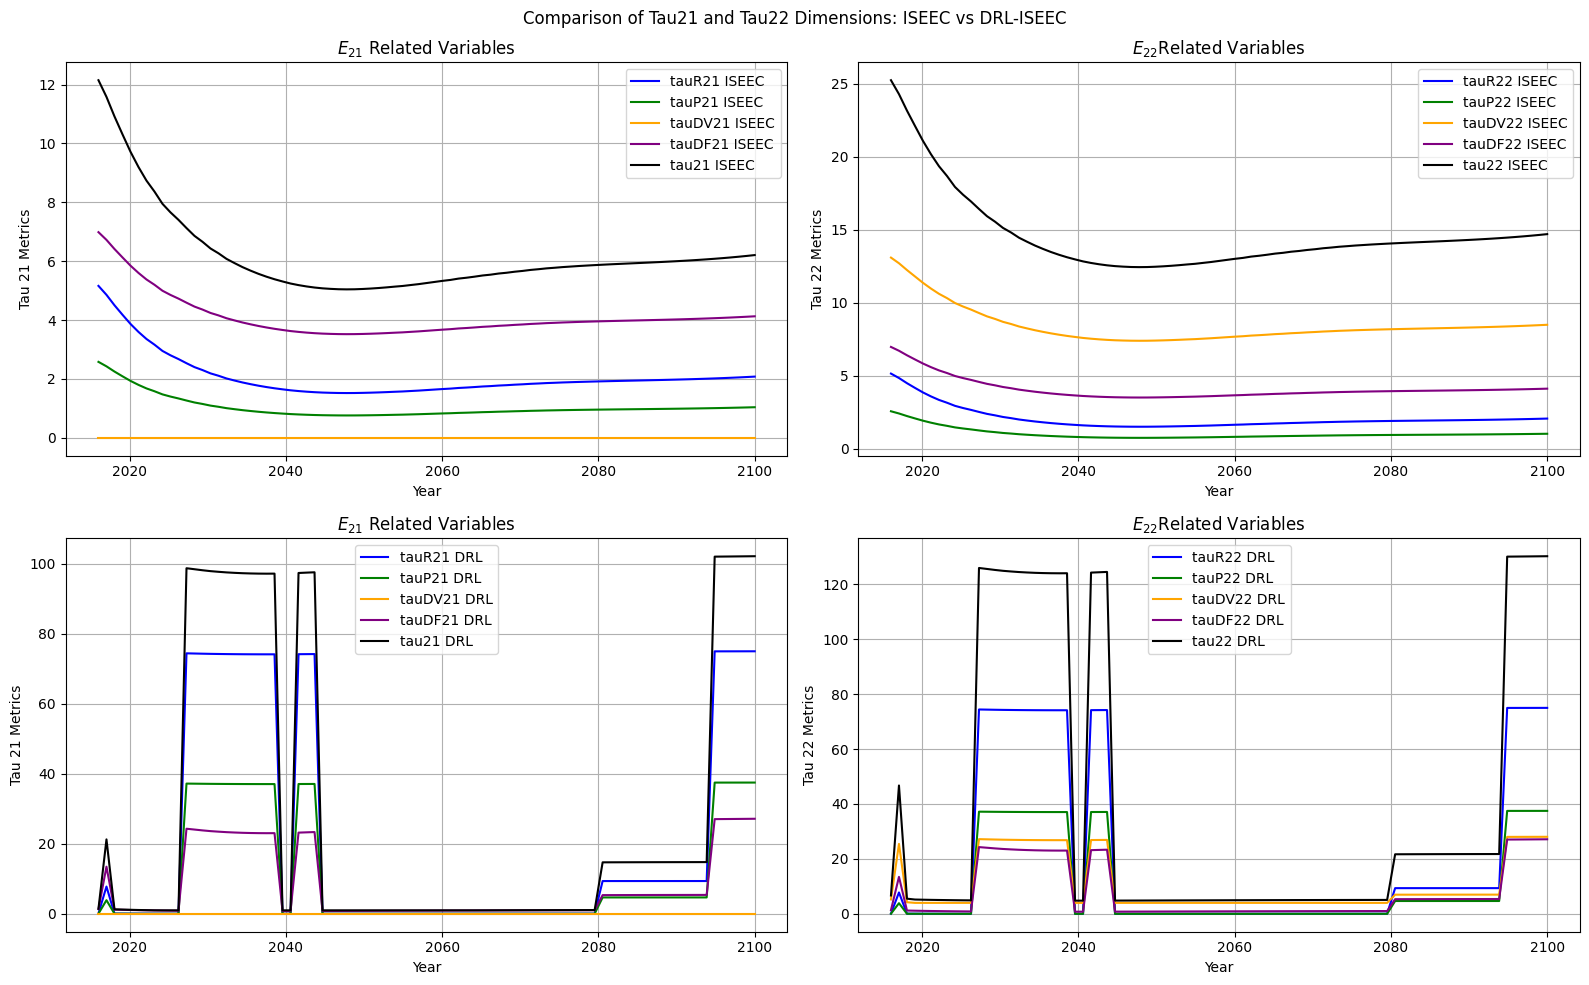

In [25]:
# 动作详细值分析
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import sys
import os
from src.envs.iseec_lx_v5_pomdp_without_masking_all_actions import IEMEnv
sys.path.append(os.path.abspath('src'))
import matplotlib.pyplot as plt

custom_reward_type = "weight_three_obj_over"
env = IEMEnv(reward_type=custom_reward_type)

years = np.linspace(2016, 2100, 83)

# 读取第一维度数据:iseec-default
df_83_type1 = pd.read_excel(rf"data\compare_data\250723 v1_default_action13\episode_0_results_20250724_202537.xlsx")
df_251_type1 = pd.read_excel(rf"data\compare_data\250723 v1_default_action13\iseec_ssp5_MIT_data_diy_weight_three_obj_over_fixed_action_13.xlsx")

# 读取第二维度数据 drl-iseec-DQN-iseec_lx_v5_ste_without_masking_DQN_weight_three_obj_over_900000_default（管控温度目前最合理的数值）
df_83_type2 = pd.read_excel(rf"data\compare_data\250724 V1 weight_three_obj_over\episode_0_results_20250724_201830.xlsx")
df_251_type2 = pd.read_excel(rf"data\compare_data\250724 V1 weight_three_obj_over\iseec_ssp5_MIT_data_diy_weight_three_obj_over_sever_trained.xlsx")

# 从 df_251 读取
tauR21_type1 = df_251_type1['taoR21']
tauP21_type1 = df_251_type1['taoP21']
tauDV21_type1 = df_251_type1['taoDV21']
tauDF21_type1 = df_251_type1['taoDF21']
tau21_type1 = df_251_type1['tao21']

tauR21_type2 = df_251_type2['taoR21']
tauP21_type2 = df_251_type2['taoP21']
tauDV21_type2 = df_251_type2['taoDV21']
tauDF21_type2 = df_251_type2['taoDF21']
tau21_type2 = df_251_type2['tao21']

tauR22_type1 = df_251_type1['taoR22']
tauP22_type1 = df_251_type1['taoP22']
tauDV22_type1 = df_251_type1['taoDV22']
tauDF22_type1 = df_251_type1['taoDF22']
tau22_type1 = df_251_type1['tao22']

tauR22_type2 = df_251_type2['taoR22']
tauP22_type2 = df_251_type2['taoP22']
tauDV22_type2 = df_251_type2['taoDV22']
tauDF22_type2 = df_251_type2['taoDF22']
tau22_type2 = df_251_type2['tao22']

fig, axes = plt.subplots(2, 2, figsize=(16, 10))

# 第一幅图：tau 21 相关
ax1 = axes[0, 0]
ax1.plot(years, tauR21_type1[-83:], label='tauR21 ISEEC', color='blue')
ax1.plot(years, tauP21_type1[-83:], label='tauP21 ISEEC', color='green')
ax1.plot(years, tauDV21_type1[-83:], label='tauDV21 ISEEC', color='orange')
ax1.plot(years, tauDF21_type1[-83:], label='tauDF21 ISEEC', color='purple')
ax1.plot(years, tau21_type1[-83:], label='tau21 ISEEC', color='black')

ax1.set_title('$E_{21}$ Related Variables')
ax1.set_xlabel('Year')
ax1.set_ylabel('Tau 21 Metrics')
ax1.legend()
ax1.grid(True)

ax2 = axes[0, 1]
ax2.plot(years, tauR22_type1[-83:], label='tauR22 ISEEC', color='blue')
ax2.plot(years, tauP22_type1[-83:], label='tauP22 ISEEC', color='green')
ax2.plot(years, tauDV22_type1[-83:], label='tauDV22 ISEEC', color='orange')
ax2.plot(years, tauDF22_type1[-83:], label='tauDF22 ISEEC', color='purple')
ax2.plot(years, tau22_type1[-83:], label='tau22 ISEEC', color='black')

ax2.set_title('$E_{22}$Related Variables')
ax2.set_xlabel('Year')
ax2.set_ylabel('Tau 22 Metrics')
ax2.legend()
ax2.grid(True)

ax3 = axes[1, 0]
ax3.plot(years, tauR21_type2[-83:], label='tauR21 DRL', color='blue')
ax3.plot(years, tauP21_type2[-83:], label='tauP21 DRL', color='green')
ax3.plot(years, tauDV21_type2[-83:], label='tauDV21 DRL', color='orange')
ax3.plot(years, tauDF21_type2[-83:], label='tauDF21 DRL', color='purple')
ax3.plot(years, tau21_type2[-83:], label='tau21 DRL', color='black')

ax3.set_title('$E_{21}$ Related Variables')
ax3.set_xlabel('Year')
ax3.set_ylabel('Tau 21 Metrics')
ax3.legend()
ax3.grid(True)

ax4 = axes[1, 1]
ax4.plot(years, tauR22_type2[-83:], label='tauR22 DRL', color='blue' )
ax4.plot(years, tauP22_type2[-83:], label='tauP22 DRL', color='green' )
ax4.plot(years, tauDV22_type2[-83:], label='tauDV22 DRL', color='orange' )
ax4.plot(years, tauDF22_type2[-83:], label='tauDF22 DRL', color='purple' )
ax4.plot(years, tau22_type2[-83:], label='tau22 DRL', color='black')

ax4.set_title('$E_{22}$Related Variables')
ax4.set_xlabel('Year')
ax4.set_ylabel('Tau 22 Metrics')
ax4.legend()
ax4.grid(True)

plt.suptitle('Comparison of Tau21 and Tau22 Dimensions: ISEEC vs DRL-ISEEC')
plt.tight_layout()
plt.show()


No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.


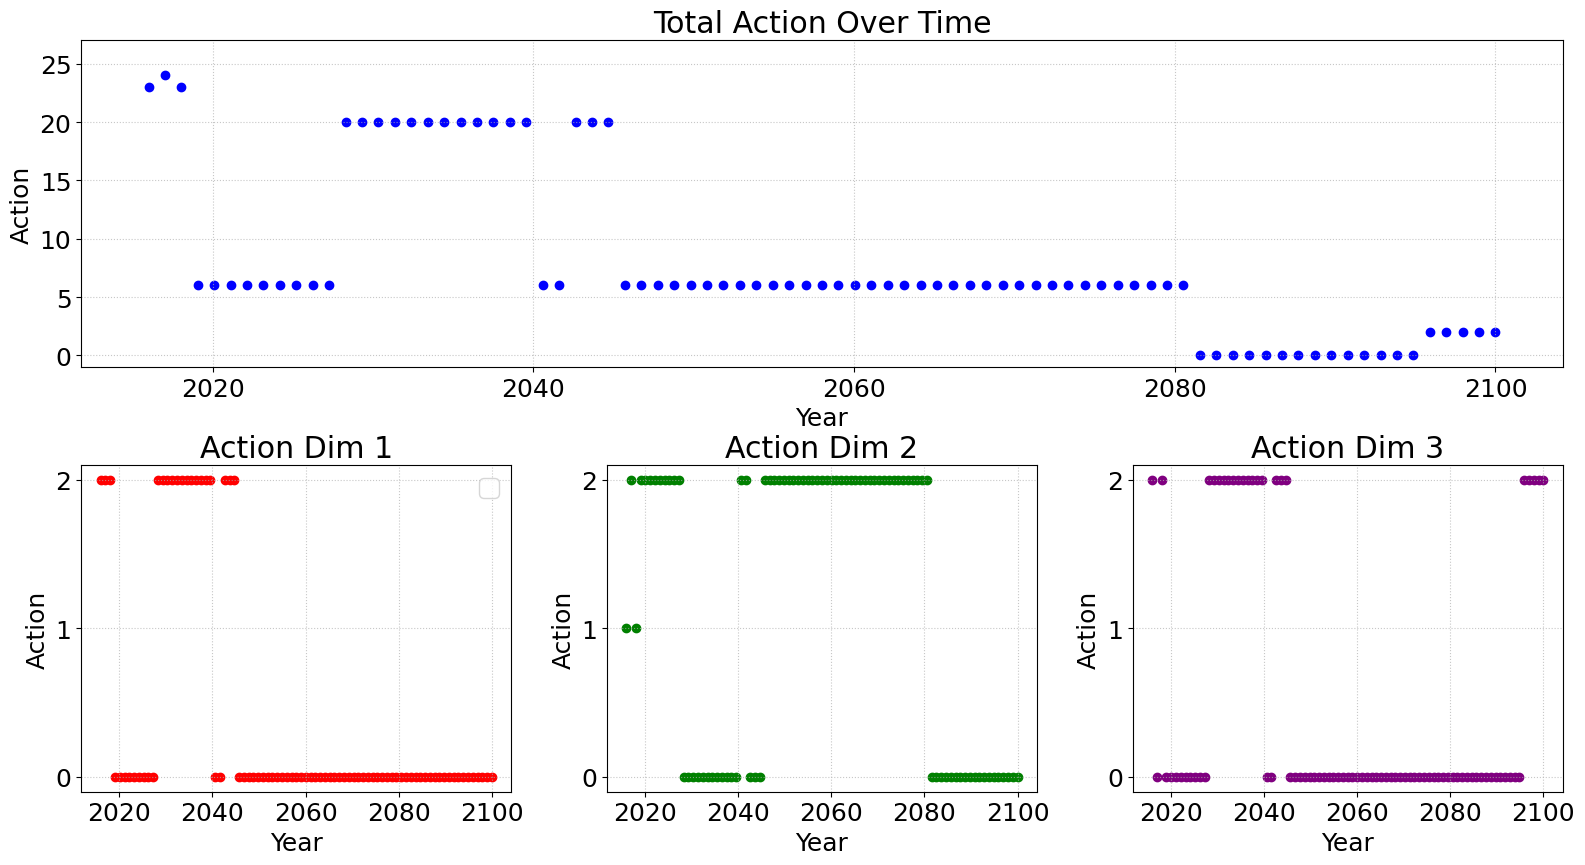

In [38]:
# 分析动作的选择对应
from cProfile import label
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec # 导入 gridspec

plt.rcParams.update({'font.size': 18})

# 读取数据
df_83_type1 = pd.read_excel(rf"data\compare_data\250724 V1 weight_three_obj_over\episode_0_results_20250724_201830.xlsx")

action_total_type1 = df_83_type1['action_0']
action_dim1_type1 = df_83_type1['action_dim1']
action_dim2_type1 = df_83_type1['action_dim2']
action_dim3_type1 = df_83_type1['action_dim3']

# 创建 figure
fig = plt.figure(figsize=(18, 10)) # 调整整体图的大小
gs = gridspec.GridSpec(2, 3)

years = np.linspace(2016, 2100, 83)

# 第一行的大图：占据第一行所有 3 列
ax_total = fig.add_subplot(gs[0, :]) # gs[0, :] 表示第0行，所有列
ax_total.scatter(years, action_total_type1,  color='blue')
ax_total.set_title('Total Action Over Time')
ax_total.set_ylabel('Action')
ax_total.set_xlabel('Year')
ax_total.set_ylim(-1, 27)
ax_total.grid(True, linestyle=':', alpha=0.7) # 重新启用网格线，并美化

# 第二行的三个小图：分别占据第二行的第 0, 1, 2 列
ax_dim1 = fig.add_subplot(gs[1, 0]) # gs[1, 0] 表示第1行，第0列
ax_dim1.scatter(years, action_dim1_type1,  color='red')
ax_dim1.set_title('Action Dim 1')
ax_dim1.set_ylabel('Action')
ax_dim1.set_xlabel('Year')
ax_dim1.grid(True, linestyle=':', alpha=0.7) # 重新启用网格线，并美化
ax_dim1.set_yticks([0, 1, 2])

ax_dim1.legend()
        
ax_dim2 = fig.add_subplot(gs[1, 1]) # gs[1, 1] 表示第1行，第1列
ax_dim2.scatter(years, action_dim2_type1,  color='green')
ax_dim2.set_title('Action Dim 2')
ax_dim2.set_ylabel('Action')
ax_dim2.set_xlabel('Year')
ax_dim2.grid(True, linestyle=':', alpha=0.7) # 重新启用网格线，并美化
ax_dim2.set_yticks([0, 1, 2])

ax_dim3 = fig.add_subplot(gs[1, 2]) # gs[1, 2] 表示第1行，第2列
ax_dim3.scatter(years, action_dim3_type1,  color='purple')
ax_dim3.set_title('Action Dim 3')
ax_dim3.set_ylabel('Action')
ax_dim3.set_xlabel('Year')
ax_dim3.grid(True, linestyle=':', alpha=0.7) # 重新启用网格线，并美化
ax_dim3.set_yticks([0, 1, 2])
# ax_dim3.grid(True)

plt.tight_layout(rect=[0.05, 0.05, 0.95, 0.95])
plt.subplots_adjust(hspace=0.3) # 可以尝试 0.3 或更小的值，例如 0.25
plt.show()


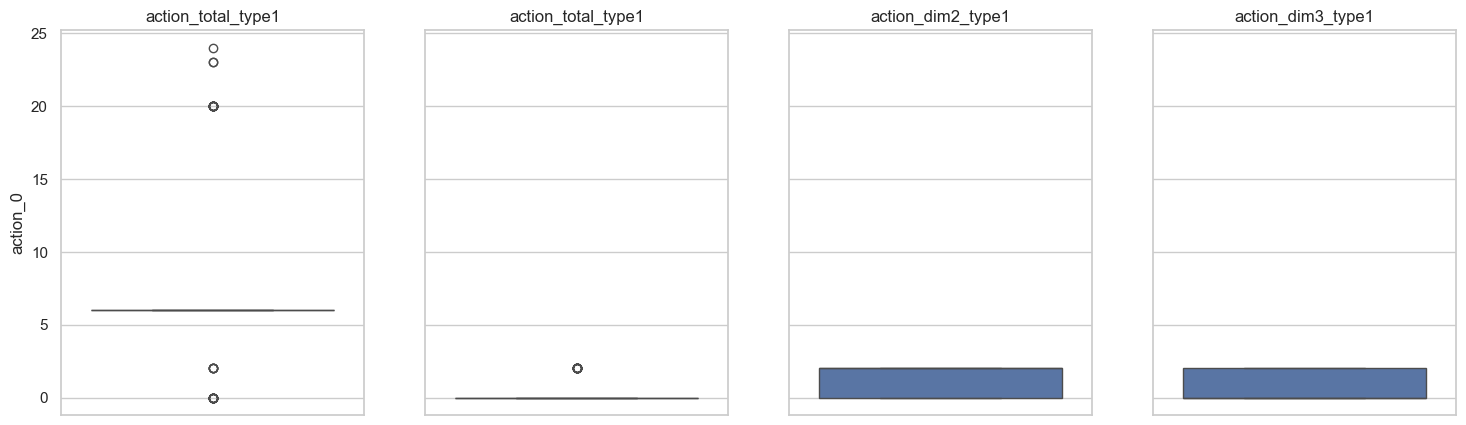

In [26]:
# 绘制动作的分布图，解释政策的变化
import matplotlib.pyplot as plt
import seaborn as sns

# 读取数据  drl-iseec-DQN-iseec_lx_v5_ste_without_masking_DQN_weight_three_obj_over_900000_default（管控温度目前最合理的数值）
df_83_type1 = pd.read_excel(rf"data\compare_data\250724 V1 weight_three_obj_over\episode_0_results_20250724_201830.xlsx")

# 设置风格
sns.set(style="whitegrid")

# 绘制各动作维度的箱线图
fig, axes = plt.subplots(1, 4, figsize=(18, 5), sharey=True)

action_total_type1 = df_83_type1['action_0']
action_dim1_type1 = df_83_type1['action_dim1']
action_dim2_type1 = df_83_type1['action_dim2']
action_dim3_type1 = df_83_type1['action_dim3']

# 绘制总动作的箱线图
sns.boxplot(data=action_total_type1, ax=axes[0])
axes[0].set_title('action_total_type1')

# 绘制第一维度的箱线图
sns.boxplot(data=action_dim1_type1, ax=axes[1])
axes[1].set_title('action_total_type1')

# 绘制第二维度的箱线图
sns.boxplot(data=action_dim2_type1, ax=axes[2])
axes[2].set_title('action_dim2_type1')

# 绘制第三维度的箱线图
sns.boxplot(data=action_dim3_type1, ax=axes[3])
axes[3].set_title('action_dim3_type1')      

plt.show()


# different reward 绘制变化

[1850 1851 1852 1853 1854 1855 1856 1857 1858 1859 1860 1861 1862 1863
 1864 1865 1866 1867 1868 1869 1870 1871 1872 1873 1874 1875 1876 1877
 1878 1879 1880 1881 1882 1883 1884 1885 1886 1887 1888 1889 1890 1891
 1892 1893 1894 1895 1896 1897 1898 1899 1900 1901 1902 1903 1904 1905
 1906 1907 1908 1909 1910 1911 1912 1913 1914 1915 1916 1917 1918 1919
 1920 1921 1922 1923 1924 1925 1926 1927 1928 1929 1930 1931 1932 1933
 1934 1935 1936 1937 1938 1939 1940 1941 1942 1943 1944 1945 1946 1947
 1948 1949 1950 1951 1952 1953 1954 1955 1956 1957 1958 1959 1960 1961
 1962 1963 1964 1965 1966 1967 1968 1969 1970 1971 1972 1973 1974 1975
 1976 1977 1978 1979 1980 1981 1982 1983 1984 1985 1986 1987 1988 1989
 1990 1991 1992 1993 1994 1995 1996 1997 1998 1999 2000 2001 2002 2003
 2004 2005 2006 2007 2008 2009 2010 2011 2012 2013 2014 2015 2016 2017
 2018 2019 2020 2021 2022 2023 2024 2025 2026 2027 2028 2029 2030 2031
 2032 2033 2034 2035 2036 2037 2038 2039 2040 2041 2042 2043 2044 2045
 2046 

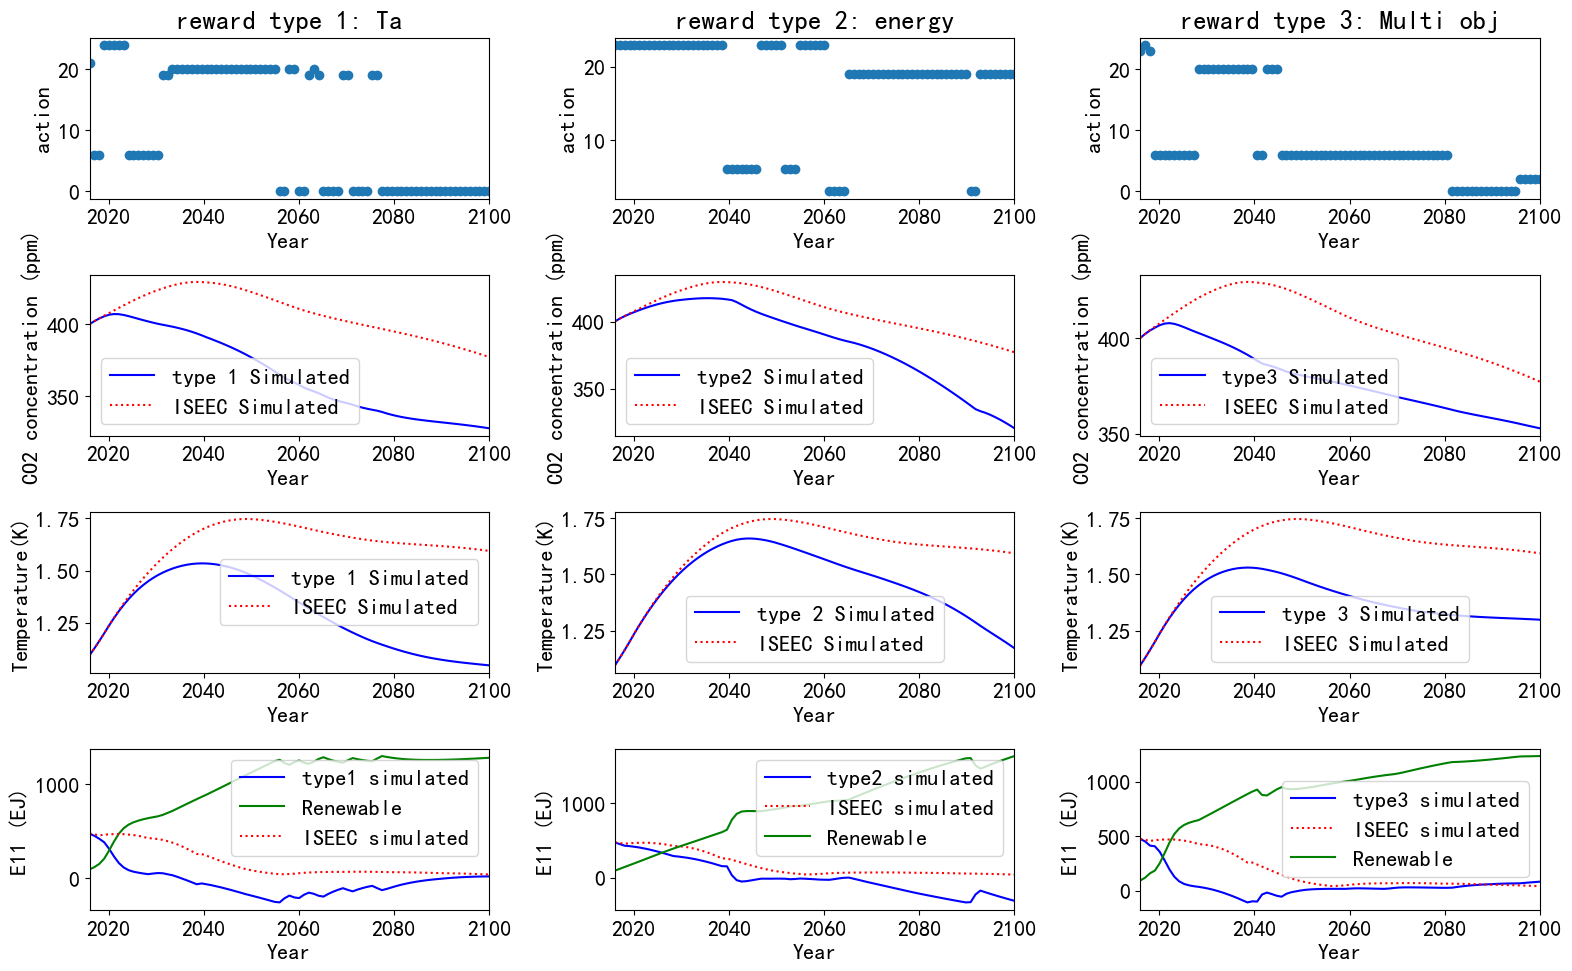

In [33]:

# 绘制不同 Reward 下的状态变化
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import sys
import os
from src.envs.iseec_lx_v5_pomdp_without_masking_all_actions_re import IEMEnv
sys.path.append(os.path.abspath('src'))
import matplotlib.pyplot as plt

years = np.linspace(2016, 2100, 83)
custom_reward_type = "distance_with_normalized_over"
env = IEMEnv(reward_type=custom_reward_type)

# 增加基准：iseec default 1.58 action=13 默认对比数据
df_83_baseline1 = pd.read_excel(rf"data\compare_data\250723 v1_default_action13\episode_0_results_20250724_202537.xlsx")
df_251_baseline1 = pd.read_excel(rf"data\compare_data\250723 v1_default_action13\iseec_ssp5_MIT_data_diy_weight_three_obj_over_fixed_action_13.xlsx")

# 读取第一维度数据: Ta-test
df_83_type1 = pd.read_excel(rf"data\compare_data\250723 V1 Ta reward\Ta_episode_0_results_20250723_213622.xlsx")
df_251_type1 = pd.read_excel(rf"data\compare_data\250723 V1 Ta reward\iseec_ssp5_MIT_data_diy_weight_three_obj_over_Ta_Ta_weight_three_obj_over_Ta.xlsx")

# 读取第二维度: energy
df_83_type2 = pd.read_excel(rf"data\compare_data\250723 V1 energy reward\episode_0_results_20250723_214912.xlsx")
df_251_type2 = pd.read_excel(rf"data\compare_data\250723 V1 energy reward\iseec_ssp5_MIT_data_diy_weight_three_obj_over_energy_energy.xlsx")

# 读取第三维度数据 multi obj
df_83_type3 = pd.read_excel(rf"data\compare_data\250724 V1 weight_three_obj_over\episode_0_results_20250724_201830.xlsx")
df_251_type3 = pd.read_excel(rf"data\compare_data\250724 V1 weight_three_obj_over\iseec_ssp5_MIT_data_diy_weight_three_obj_over_sever_trained.xlsx")

# compare data 的相关变量
T_a_baseline1 = df_83_baseline1['T_a']
C_a_baseline1 = df_83_baseline1['C_a']
energy_MYadjusted18502100_total_plus_B3B_plus_ACE3_baseline1 = df_251_baseline1['energy_MYadjusted18502100_total_plus_B3B_plus_ACE3']
energy_MYbaseline18502100_total_formulated = df_251_baseline1['energy_MYbaseline18502100_total_formulated']
E11_baseline1 = [
    energy - e12 - e21 - e22 - e23 - e24
    for energy, e12, e21, e22, e23, e24 in zip(
        energy_MYadjusted18502100_total_plus_B3B_plus_ACE3_baseline1[-83:], df_83_baseline1['E12'], df_83_baseline1['E21'], df_83_baseline1['E22'], df_83_baseline1['E23'],df_83_baseline1['E24']
    )
]
re_baseline1 = [
    e_adjusted / e_all
    for e_adjusted, e_all in zip(
        energy_MYadjusted18502100_total_plus_B3B_plus_ACE3_baseline1, 
        energy_MYbaseline18502100_total_formulated
    )
][-83:]

# type 1 的相关变量
action_total_type1 = df_83_type1['action_0']
T_a_type1 = df_83_type1['T_a']
C_a_type1 = df_83_type1['C_a']
CO2emission_actualFF_type1 = df_251_type1['CO2emission_actualFF']
CO2emission_ACE1_type1 = df_251_type1['CO2emission_ACE1']
CO2emission_ACE2_type1 = df_251_type1['CO2emission_ACE2']
CO2emission_ACE3_type1 = df_251_type1['CO2emission_ACE3']
ratio_net_over_gross_type1 = df_251_type1['ratio_net_over_gross']
energy_MYadjusted18502100_total_plus_B3B_plus_ACE3_type1 = df_251_type1['energy_MYadjusted18502100_total_plus_B3B_plus_ACE3']
# 增加对 E11 和 re 变量的绘制
# E11 的读取
E12_type1 = df_83_type1['E12']
E21_type1 = df_83_type1['E21']
E22_type1 = df_83_type1['E22']
E23_type1 = df_83_type1['E23']
E24_type1 = df_83_type1['E24']
E11_type1 = [
    energy - e12 - e21 - e22 - e23 - e24
    for energy, e12, e21, e22, e23, e24 in zip(
        energy_MYadjusted18502100_total_plus_B3B_plus_ACE3_type1[-83:], E12_type1, E21_type1, E22_type1, E23_type1, E24_type1
    )
]
# re 的读取
# 计算 re_type1 的值，并取最后 83 个元素
re_type1 = [
    e_adjusted / e_all
    for e_adjusted, e_all in zip(
        energy_MYadjusted18502100_total_plus_B3B_plus_ACE3_type1, 
        energy_MYbaseline18502100_total_formulated
    )
][-83:]

# type 2 的相关变量
action_total_type2 = df_83_type2['action_0']
T_a_type2 = df_83_type2['T_a']
C_a_type2 = df_83_type2['C_a']
CO2emission_actualFF_type2 = df_251_type2['CO2emission_actualFF']
CO2emission_ACE1_type2 = df_251_type2['CO2emission_ACE1']
CO2emission_ACE2_type2 = df_251_type2['CO2emission_ACE2']
CO2emission_ACE3_type2 = df_251_type2['CO2emission_ACE3']
ratio_net_over_gross_type2 = df_251_type2['ratio_net_over_gross']
energy_MYadjusted18502100_total_plus_B3B_plus_ACE3_type2 = df_251_type2['energy_MYadjusted18502100_total_plus_B3B_plus_ACE3']   
# E11
E12_type2 = df_83_type2['E12']
E21_type2 = df_83_type2['E21']
E22_type2 = df_83_type2['E22']
E23_type2 = df_83_type2['E23']
E24_type2 = df_83_type2['E24']
E11_type2 = [
    energy - e12 - e21 - e22 - e23 - e24
    for energy, e12, e21, e22, e23, e24 in zip(
        energy_MYadjusted18502100_total_plus_B3B_plus_ACE3_type2[-83:], E12_type2, E21_type2, E22_type2, E23_type2, E24_type2
    )
]
re_type2 = [
    e_adjusted / e_all
    for e_adjusted, e_all in zip(
        energy_MYadjusted18502100_total_plus_B3B_plus_ACE3_type2, 
        energy_MYbaseline18502100_total_formulated
    )
][-83:]

# type 3 的相关变量
action_total_type3 = df_83_type3['action_0']
T_a_type3 = df_83_type3['T_a']
C_a_type3 = df_83_type3['C_a']
CO2emission_actualFF_type3 = df_251_type3['CO2emission_actualFF']
CO2emission_ACE1_type3 = df_251_type3['CO2emission_ACE1']
CO2emission_ACE2_type3 = df_251_type3['CO2emission_ACE2']
CO2emission_ACE3_type3 = df_251_type3['CO2emission_ACE3']
ratio_net_over_gross_type3 = df_251_type3['ratio_net_over_gross']
energy_MYadjusted18502100_total_plus_B3B_plus_ACE3_type3 = df_251_type3['energy_MYadjusted18502100_total_plus_B3B_plus_ACE3']   
# E11
E12_type3 = df_83_type3['E12']
E21_type3 = df_83_type3['E21']
E22_type3 = df_83_type3['E22']
E23_type3 = df_83_type3['E23']
E24_type3 = df_83_type3['E24']
E11_type3 = [
    energy - e12 - e21 - e22 - e23 - e24
    for energy, e12, e21, e22, e23, e24 in zip(
        energy_MYadjusted18502100_total_plus_B3B_plus_ACE3_type3[-83:], E12_type3, E21_type3, E22_type3, E23_type3, E24_type3
    )
]
re_type3 = [
    e_adjusted / e_all
    for e_adjusted, e_all in zip(
        energy_MYadjusted18502100_total_plus_B3B_plus_ACE3_type3, 
        energy_MYbaseline18502100_total_formulated
    )
][-83:]

# 开始绘制
fig, axes = plt.subplots(4, 3, figsize=(16, 10))

xlim = (2016, 2100)

ax1 = axes[0, 0]
# 利用散点图绘制 action
ax1.scatter(years, action_total_type1)
ax1.set_xlabel('Year')
ax1.set_ylabel('action')
ax1.set_title('reward type 1: Ta')
ax1.set_xlim(xlim)

# 利用散点图绘制 action
ax2 = axes[0, 1]
ax2.scatter(years, action_total_type2)
ax2.set_xlabel('Year')
ax2.set_ylabel('action')
ax2.set_title('reward type 2: energy')
ax2.set_xlim(xlim)

# 利用散点图绘制 action
ax3 = axes[0, 2]
ax3.scatter(years, action_total_type3)
ax3.set_xlabel('Year')
ax3.set_ylabel('action')
ax3.set_title('reward type 3: Multi obj')
ax3.set_xlim(xlim)

ax4 = axes[1, 0]
ax4.plot(years, C_a_type1 * env.rho_a, label='type 1 Simulated', color='blue') # env.rho_a 约等于 0.4629629629629629
ax4.plot(years, C_a_baseline1 * env.rho_a, label='ISEEC Simulated', linestyle='dotted', color='red') # env.rho_a 约等于 0.4629629629629629
# ax4.plot(env.IAM_CO2concentration.iloc[2-2,4:].astype('float') , label = 'IAMs',linestyle='dotted', marker='',color = 'blue')
# ax4.plot(env.IAM_CO2concentration.iloc[3-2,4:].astype('float') , linestyle='dotted', marker='',color = 'blue')
# ax4.plot(env.IAM_CO2concentration.iloc[4-2,4:].astype('float') , linestyle='dotted', marker='',color = 'blue')
# ax4.plot(env.IAM_CO2concentration.iloc[5-2,4:].astype('float') , linestyle='dotted', marker='',color = 'blue')
ax4.set_ylabel("CO2 concentration (ppm)")
ax4.set_xlabel('Year')
ax4.set_xlim(xlim)
ax4.legend()

ax5 = axes[1, 1]
ax5.plot(years, C_a_type2 * env.rho_a, label='type2 Simulated', color='blue') # env.rho_a 约等于 0.4629629629629629
ax5.plot(years, C_a_baseline1 * env.rho_a, label='ISEEC Simulated', linestyle='dotted', color='red') # env.rho_a 约等于 0.4629629629629629
ax5.set_ylabel("CO2 concentration (ppm)")
ax5.set_xlabel('Year')
ax5.set_xlim(xlim)
ax5.legend()

ax6 = axes[1, 2]
ax6.plot(years, C_a_type3 * env.rho_a, label='type3 Simulated', color='blue') # env.rho_a 约等于 0.4629629629629629
ax6.plot(years, C_a_baseline1 * env.rho_a, label='ISEEC Simulated', linestyle='dotted', color='red') # env.rho_a 约等于 0.4629629629629629
ax6.set_ylabel("CO2 concentration (ppm)")
ax6.set_xlabel('Year')
ax6.set_xlim(xlim)
ax6.legend()

# 绘制 Ta
ax7 = axes[2, 0]
ax7.plot(years, T_a_type1, label='type 1 Simulated', color='blue') # env.rho_a 约等于 0.4629629629629629
ax7.plot(years, T_a_baseline1, label='ISEEC Simulated', linestyle='dotted', color='red') # env.rho_a 约等于 0.4629629629629629
ax7.set_ylabel("Temperature(K)")
ax7.set_xlabel('Year')
ax7.set_xlim(xlim)
ax7.legend()

ax8 = axes[2, 1]
ax8.plot(years, T_a_type2, label='type 2 Simulated', color='blue') # env.rho_a 约等于 0.4629629629629629
ax8.plot(years, T_a_baseline1, label='ISEEC Simulated', linestyle='dotted', color='red') # env.rho_a 约等于 0.4629629629629629
ax8.set_ylabel("Temperature(K)")
ax8.set_xlabel('Year')
ax8.set_xlim(xlim)
ax8.legend()

ax9 = axes[2, 2]
ax9.plot(years, T_a_type3, label='type 3 Simulated', color='blue') # env.rho_a 约等于 0.4629629629629629
ax9.plot(years, T_a_baseline1, label='ISEEC Simulated', linestyle='dotted', color='red') # env.rho_a 约等于 0.4629629629629629,linestyle='dotted'
ax9.set_ylabel("Temperature(K)")
ax9.set_xlabel('Year')
ax9.set_xlim(xlim)
ax9.legend()

# 绘制 energy 
# ax10 = axes[3, 0]
# ax10.plot(years, energy_MYadjusted18502100_total_plus_B3B_plus_ACE3_type1[-83:], 
#         label='type1 simulated', color='blue')
# ax10.plot(years, energy_MYadjusted18502100_total_plus_B3B_plus_ACE3_baseline1[-83:], 
#         label='ISEEC simulated', linestyle='dotted', color='red')
# ax10.set_ylabel('Total Energy (EJ)')
# ax10.set_xlabel('Year')
# ax10.set_xlim(xlim)
# ax10.legend()

# ax11 = axes[3, 1]
# ax11.plot(years, energy_MYadjusted18502100_total_plus_B3B_plus_ACE3_type2[-83:], 
#         label='type2 simulated', color='blue')
# ax11.plot(years, energy_MYadjusted18502100_total_plus_B3B_plus_ACE3_baseline1[-83:], 
#         label='ISEEC simulated', linestyle='dotted', color='red')
# ax11.set_ylabel('Total Energy (EJ)')
# ax11.set_xlabel('Year')
# ax11.set_xlim(xlim)
# ax11.legend()

# ax12 = axes[3, 2]
# ax12.plot(years, energy_MYadjusted18502100_total_plus_B3B_plus_ACE3_type3[-83:], 
#         label='type3 simulated', color='blue')
# ax12.plot(years, energy_MYadjusted18502100_total_plus_B3B_plus_ACE3_baseline1[-83:], 
#         label='ISEEC simulated',  linestyle='dotted', color='red')
# ax12.set_ylabel('Total Energy (EJ)')
# ax12.set_xlabel('Year')
# ax12.set_xlim(xlim)
# ax12.legend()

# 绘制 E11
ax10 = axes[3, 0]
ax10.plot(years, E11_type1, 
        label='type1 simulated', color='blue')
ax10.plot(years, E21_type1 + E22_type1 + E23_type1 + E24_type1, label = 'Renewable',color = 'green',linestyle = 'solid')
ax10.plot(years, E11_baseline1, 
        label='ISEEC simulated', linestyle='dotted', color='red')
# ax10.plot(years, [a+b+c for a,b,c in zip(np.cumsum(CO2emission_ACE1_type1)*44/12,np.cumsum(CO2emission_ACE2_type1)*44/12,np.cumsum(CO2emission_ACE3_type1)*44/12)][-83:], label = 'ACE1+2+3',color = 'red',linestyle = 'solid')
ax10.set_ylabel('E11 (EJ)')
ax10.set_xlabel('Year')
ax10.set_xlim(xlim)
ax10.legend()

ax11 = axes[3, 1]
ax11.plot(years, E11_type2,
        label='type2 simulated', color='blue')
ax11.plot(years, E11_baseline1, 
        label='ISEEC simulated', linestyle='dotted', color='red')
ax11.plot(years, E21_type2 + E22_type2 + E23_type2 + E24_type2, label = 'Renewable',color = 'green',linestyle = 'solid')
ax11.set_ylabel('E11 (EJ)')
ax11.set_xlabel('Year')
ax11.set_xlim(xlim)
ax11.legend()

ax12 = axes[3, 2]
ax12.plot(years, E11_type3,
        label='type3 simulated', color='blue')
ax12.plot(years, E11_baseline1, 
        label='ISEEC simulated', linestyle='dotted', color='red')
ax12.plot(years, E21_type3 + E22_type3 + E23_type3 + E24_type3, label = 'Renewable',color = 'green',linestyle = 'solid')
ax12.set_ylabel('E11 (EJ)')
ax12.set_xlabel('Year')
ax12.set_xlim(xlim)
ax12.legend()

# 绘制 re
# ax10 = axes[3, 0]
# ax10.plot(years, re_type1, 
#         label='type1 simulated', color='blue')
# ax10.plot(years, re_baseline1, 
#         label='ISEEC simulated', linestyle='dotted', color='red')
# ax10.set_ylabel('Energy intensity (EJ/TrillionUSD)') # EJ/TrillionUSD
# ax10.set_xlabel('Year')
# ax10.set_xlim(xlim)
# ax10.legend()

# ax11 = axes[3, 1]
# ax11.plot(years, re_type2,
#         label='type2 simulated', color='blue')
# ax11.plot(years, re_baseline1, 
#         label='ISEEC simulated', linestyle='dotted', color='red')
# ax11.set_ylabel('Energy intensity (EJ/TrillionUSD)') # EJ/TrillionUSD
# ax11.set_xlabel('Year')
# ax11.set_xlim(xlim)
# ax11.legend()

# ax12 = axes[3, 2]
# ax12.plot(years, re_type3,
#         label='type3 simulated', color='blue')
# ax12.plot(years, re_baseline1, 
#         label='ISEEC simulated', linestyle='dotted', color='red')
# ax12.set_ylabel('Energy intensity (EJ/TrillionUSD)') # EJ/TrillionUSD
# ax12.set_xlabel('Year')
# ax12.set_xlim(xlim)
# ax12.legend()

# 调整布局以防止标签重叠
plt.tight_layout()
# 显示绘图
plt.show()


[1850 1851 1852 1853 1854 1855 1856 1857 1858 1859 1860 1861 1862 1863
 1864 1865 1866 1867 1868 1869 1870 1871 1872 1873 1874 1875 1876 1877
 1878 1879 1880 1881 1882 1883 1884 1885 1886 1887 1888 1889 1890 1891
 1892 1893 1894 1895 1896 1897 1898 1899 1900 1901 1902 1903 1904 1905
 1906 1907 1908 1909 1910 1911 1912 1913 1914 1915 1916 1917 1918 1919
 1920 1921 1922 1923 1924 1925 1926 1927 1928 1929 1930 1931 1932 1933
 1934 1935 1936 1937 1938 1939 1940 1941 1942 1943 1944 1945 1946 1947
 1948 1949 1950 1951 1952 1953 1954 1955 1956 1957 1958 1959 1960 1961
 1962 1963 1964 1965 1966 1967 1968 1969 1970 1971 1972 1973 1974 1975
 1976 1977 1978 1979 1980 1981 1982 1983 1984 1985 1986 1987 1988 1989
 1990 1991 1992 1993 1994 1995 1996 1997 1998 1999 2000 2001 2002 2003
 2004 2005 2006 2007 2008 2009 2010 2011 2012 2013 2014 2015 2016 2017
 2018 2019 2020 2021 2022 2023 2024 2025 2026 2027 2028 2029 2030 2031
 2032 2033 2034 2035 2036 2037 2038 2039 2040 2041 2042 2043 2044 2045
 2046 

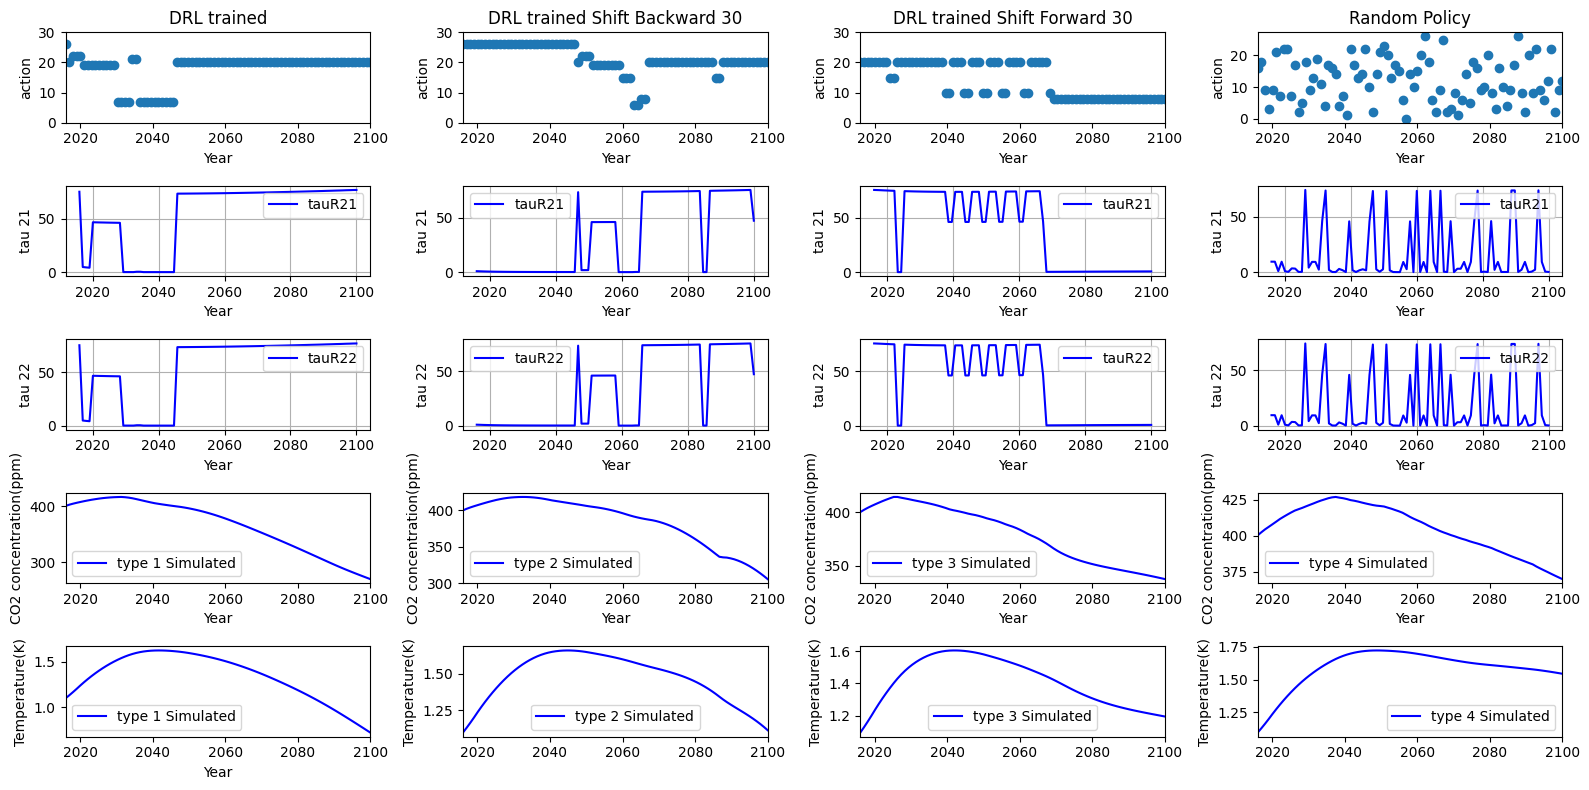

In [ ]:
# 绘制不同动作下参数变化对于系统的影响
# 绘制向前30年和向后30年的结果变化

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import sys
import os
from src.envs.iseec_lx_v5_pomdp_without_masking_all_actions import IEMEnv
sys.path.append(os.path.abspath('src'))
import matplotlib.pyplot as plt

years = np.linspace(2016, 2100, 83)
custom_reward_type = "distance_with_normalized_over"
env = IEMEnv(reward_type=custom_reward_type)

# 增加基准：iseec default 1.58 action=13 默认对比数据
df_83_baseline1 = pd.read_excel(f"data\compare_data\default_action13\episode_0_results_20250720_185238.xlsx")
df_251_baseline1 = pd.read_excel(f"data\compare_data\default_action13\iseec_ssp5_MIT_data_diy_distance_with_normalized_over_fixed_action13.xlsx")

# 读取 drl 正常数据
df_83_type1 = pd.read_excel(f"data\compare_data\special_time_windows_predict_action_roll\default_model_predict_dqn_distance_over\episode_0_results_20250720_185019.xlsx")
df_251_type1 = pd.read_excel(r"data\compare_data\special_time_windows_predict_action_roll\default_model_predict_dqn_distance_over\distance_with_normalized_over_v5_DQN_distance.xlsx")

# 读取向后30年数据
df_83_type2 = pd.read_excel(f"data\compare_data\special_time_windows_predict_action_roll\Shift_Backward_30\episode_0_results_20250718_175130.xlsx")
df_251_type2 = pd.read_excel(f"data\compare_data\special_time_windows_predict_action_roll\Shift_Backward_30\iseec_ssp5_MIT_data_diy_distance_with_normalized_over_Shift_Backward_30.xlsx")

# 读取向前30年数据
df_83_type3 = pd.read_excel(f"data\compare_data\special_time_windows_predict_action_roll\Shift_Forward_30\episode_0_results_20250718_174931.xlsx")
df_251_type3 = pd.read_excel(f"data\compare_data\special_time_windows_predict_action_roll\Shift_Forward_30\iseec_ssp5_MIT_data_diy_distance_with_normalized_over_exp404_Shift_Forward_30.xlsx")

# 读取没有经过训练的 agent 
df_83_type4 = pd.read_excel(rf"data\compare_data\special_time_windows_predict_action_roll\random_policy_proper_range\episode_0_results_20250718_165348.xlsx")
df_251_type4 = pd.read_excel(rf"data\compare_data\special_time_windows_predict_action_roll\random_policy_proper_range\iseec_ssp5_MIT_data_diy_weight_three_obj_random_policy.xlsx")

# 阅读变量
action_total_type1 = df_83_type1['action_0']
action_total_type2 = df_83_type2['action_0']
action_total_type3 = df_83_type3['action_0']
action_total_type4 = df_83_type4['action_0']

tauR21_type1 = df_251_type1['taoR21']
tauR21_type2 = df_251_type2['taoR21']
tauR21_type3 = df_251_type3['taoR21']
tauR21_type4 = df_251_type4['taoR21']

tauR22_type1 = df_251_type1['taoR22']
tauR22_type2 = df_251_type2['taoR22']
tauR22_type3 = df_251_type3['taoR22']
tauR22_type4 = df_251_type4['taoR22']

C_a_type1 = df_83_type1['C_a']
C_a_type2 = df_83_type2['C_a']
C_a_type3 = df_83_type3['C_a']
C_a_type4 = df_83_type4['C_a']

T_a_type1 = df_83_type1['T_a']
T_a_type2 = df_83_type2['T_a']
T_a_type3 = df_83_type3['T_a']
T_a_type4 = df_83_type4['T_a']


# 开始绘制
fig, axes = plt.subplots(5, 4, figsize=(16, 8))

# 统一的x轴
xlim = (2016, 2100)

ax1 = axes[0, 0]
ax1.scatter(years, action_total_type1)
ax1.set_xlabel('Year')
ax1.set_ylabel('action')
ax1.set_title('DRL trained')
ax1.set_ylim(0, 30)
ax1.set_xlim(xlim)

ax2 = axes[0, 1]
ax2.scatter(years, action_total_type2)
ax2.set_xlabel('Year')
ax2.set_ylabel('action')
ax2.set_title('DRL trained Shift Backward 30')
ax2.set_ylim(0, 30)
ax2.set_xlim(xlim)

ax3 = axes[0, 2]
ax3.scatter(years, action_total_type3)
ax3.set_xlabel('Year')
ax3.set_ylabel('action')
ax3.set_title('DRL trained Shift Forward 30')
ax3.set_ylim(0, 30)
ax3.set_xlim(xlim)

ax4 = axes[0, 3]
ax4.scatter(years, action_total_type4)
ax4.set_xlabel('Year')
ax4.set_ylabel('action')
ax4.set_title('Random Policy')
ax4.set_xlim(xlim)

ax5 = axes[1, 0]
ax5.plot(years, tauR21_type1[-83:], label='tauR21', color='blue')
ax5.set_xlabel('Year')
ax5.set_ylabel('tau 21')
ax5.legend()
ax5.grid(True)

ax6 = axes[1, 1]
ax6.plot(years, tauR21_type2[-83:], label='tauR21', color='blue')
ax6.set_xlabel('Year')
ax6.set_ylabel('tau 21')
ax6.legend()
ax6.grid(True)

ax7 = axes[1, 2]
ax7.plot(years, tauR21_type3[-83:], label='tauR21', color='blue')
ax7.set_xlabel('Year')
ax7.set_ylabel('tau 21')
ax7.legend()
ax7.grid(True)

ax8 = axes[1, 3]
ax8.plot(years, tauR21_type4[-83:], label='tauR21', color='blue')
ax8.set_xlabel('Year')
ax8.set_ylabel('tau 21')
ax8.legend()
ax8.grid(True)

ax9 = axes[2, 0]
ax9.plot(years, tauR22_type1[-83:], label='tauR22', color='blue')
ax9.set_xlabel('Year')
ax9.set_ylabel('tau 22')
ax9.legend()
ax9.grid(True)

ax10 = axes[2, 1]
ax10.plot(years, tauR22_type2[-83:], label='tauR22', color='blue')
ax10.set_xlabel('Year')
ax10.set_ylabel('tau 22')
ax10.legend()
ax10.grid(True)

ax11 = axes[2, 2]
ax11.plot(years, tauR22_type3[-83:], label='tauR22', color='blue')
ax11.set_xlabel('Year')
ax11.set_ylabel('tau 22')
ax11.legend()
ax11.grid(True)

ax12 = axes[2, 3]
ax12.plot(years, tauR22_type4[-83:], label='tauR22', color='blue')
ax12.set_xlabel('Year')
ax12.set_ylabel('tau 22')
ax12.legend()
ax12.grid(True)

ax13 = axes[3, 0]
ax13.plot(years, C_a_type1 * env.rho_a, label='type 1 Simulated', color='blue')
ax13.set_ylabel("CO2 concentration(ppm)")
ax13.set_xlabel('Year')
ax13.set_xlim(xlim)
ax13.legend()

ax14 = axes[3, 1]
ax14.plot(years, C_a_type2 * env.rho_a, label='type 2 Simulated', color='blue')
ax14.set_ylabel("CO2 concentration(ppm)")
ax14.set_xlabel('Year')
ax14.set_xlim(xlim)
ax14.legend()

ax15 = axes[3, 2]
ax15.plot(years, C_a_type3 * env.rho_a, label='type 3 Simulated', color='blue')
ax15.set_ylabel("CO2 concentration(ppm)")
ax15.set_xlabel('Year')
ax15.set_xlim(xlim)
ax15.legend()

ax16 = axes[3, 3]
ax16.plot(years, C_a_type4 * env.rho_a, label='type 4 Simulated', color='blue')
ax16.set_ylabel("CO2 concentration(ppm)")
ax16.set_xlabel('Year')
ax16.set_xlim(xlim)
ax16.legend()

ax17 = axes[4, 0]
ax17.plot(years, T_a_type1, label='type 1 Simulated', color='blue')
ax17.set_ylabel("Temperature(K)")
ax17.set_xlabel('Year')
ax17.set_xlim(xlim)
ax17.legend()

ax18 = axes[4, 1]
ax18.plot(years, T_a_type2, label='type 2 Simulated', color='blue')
ax18.set_ylabel("Temperature(K)")
ax18.set_xlim(xlim)
ax18.legend()

ax19 = axes[4, 2]
ax19.plot(years, T_a_type3, label='type 3 Simulated', color='blue')
ax19.set_ylabel("Temperature(K)")
ax19.set_xlim(xlim)
ax19.legend()

ax20 = axes[4, 3]
ax20.plot(years, T_a_type4, label='type 4 Simulated', color='blue')
ax20.set_ylabel("Temperature(K)")
ax20.set_xlim(xlim)
ax20.legend()

plt.tight_layout()
plt.show()


[1850 1851 1852 1853 1854 1855 1856 1857 1858 1859 1860 1861 1862 1863
 1864 1865 1866 1867 1868 1869 1870 1871 1872 1873 1874 1875 1876 1877
 1878 1879 1880 1881 1882 1883 1884 1885 1886 1887 1888 1889 1890 1891
 1892 1893 1894 1895 1896 1897 1898 1899 1900 1901 1902 1903 1904 1905
 1906 1907 1908 1909 1910 1911 1912 1913 1914 1915 1916 1917 1918 1919
 1920 1921 1922 1923 1924 1925 1926 1927 1928 1929 1930 1931 1932 1933
 1934 1935 1936 1937 1938 1939 1940 1941 1942 1943 1944 1945 1946 1947
 1948 1949 1950 1951 1952 1953 1954 1955 1956 1957 1958 1959 1960 1961
 1962 1963 1964 1965 1966 1967 1968 1969 1970 1971 1972 1973 1974 1975
 1976 1977 1978 1979 1980 1981 1982 1983 1984 1985 1986 1987 1988 1989
 1990 1991 1992 1993 1994 1995 1996 1997 1998 1999 2000 2001 2002 2003
 2004 2005 2006 2007 2008 2009 2010 2011 2012 2013 2014 2015 2016 2017
 2018 2019 2020 2021 2022 2023 2024 2025 2026 2027 2028 2029 2030 2031
 2032 2033 2034 2035 2036 2037 2038 2039 2040 2041 2042 2043 2044 2045
 2046 

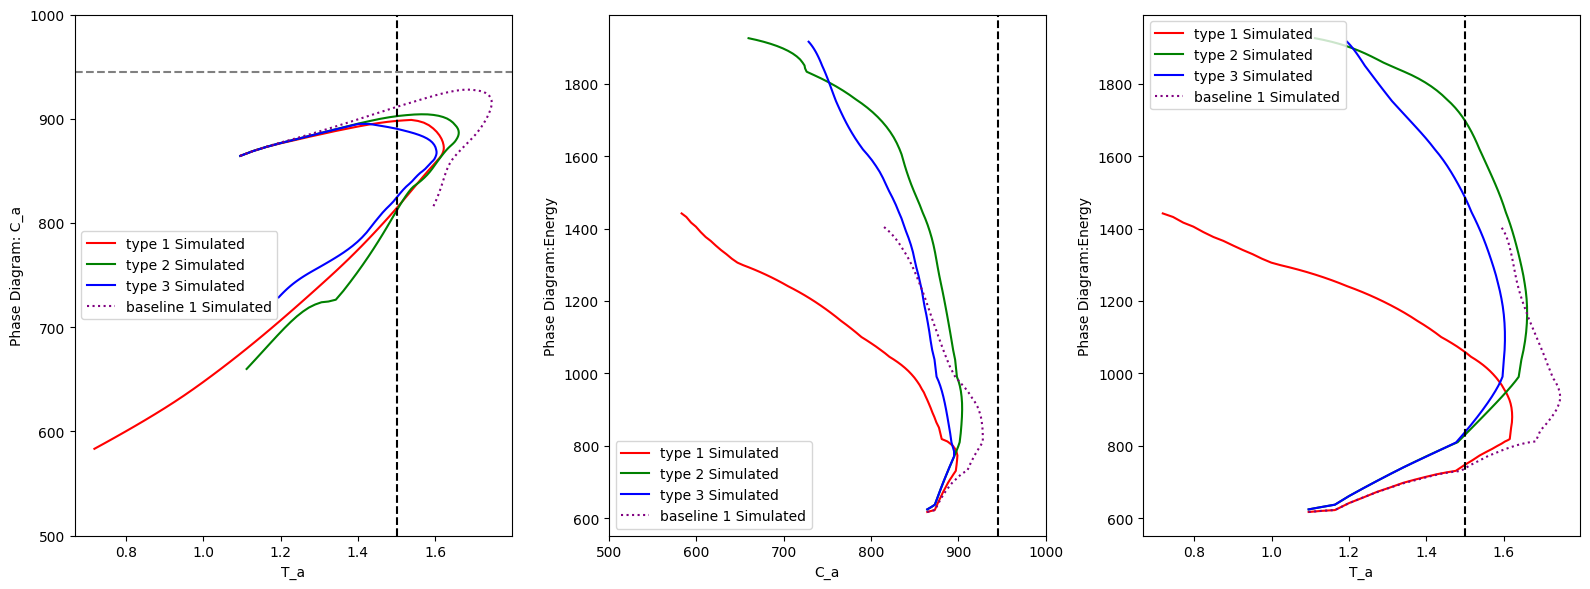

In [33]:
# 绘制二元相图
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import sys
import os
from src.envs.iseec_lx_v5_pomdp_without_masking_all_actions import IEMEnv
sys.path.append(os.path.abspath('src'))
import matplotlib.pyplot as plt

years = np.linspace(2016, 2100, 83)
custom_reward_type = "distance_with_normalized_over"
env = IEMEnv(reward_type=custom_reward_type)

# 增加基准：iseec default 1.58 action=13 默认对比数据
df_83_baseline1 = pd.read_excel(f"data\compare_data\default_action13\episode_0_results_20250720_185238.xlsx")
df_251_baseline1 = pd.read_excel(f"data\compare_data\default_action13\iseec_ssp5_MIT_data_diy_distance_with_normalized_over_fixed_action13.xlsx")

# 读取 drl 正常数据
df_83_type1 = pd.read_excel(f"data\compare_data\special_time_windows_predict_action_roll\default_model_predict_dqn_distance_over\episode_0_results_20250720_185019.xlsx")
df_251_type1 = pd.read_excel(r"data\compare_data\special_time_windows_predict_action_roll\default_model_predict_dqn_distance_over\distance_with_normalized_over_v5_DQN_distance.xlsx")

# 读取向后30年数据
df_83_type2 = pd.read_excel(f"data\compare_data\special_time_windows_predict_action_roll\Shift_Backward_30\episode_0_results_20250718_175130.xlsx")
df_251_type2 = pd.read_excel(f"data\compare_data\special_time_windows_predict_action_roll\Shift_Backward_30\iseec_ssp5_MIT_data_diy_distance_with_normalized_over_Shift_Backward_30.xlsx")

# 读取向前30年数据
df_83_type3 = pd.read_excel(f"data\compare_data\special_time_windows_predict_action_roll\Shift_Forward_30\episode_0_results_20250718_174931.xlsx")
df_251_type3 = pd.read_excel(f"data\compare_data\special_time_windows_predict_action_roll\Shift_Forward_30\iseec_ssp5_MIT_data_diy_distance_with_normalized_over_exp404_Shift_Forward_30.xlsx")

# # 读取没有经过训练的 agent 
# df_83_type4 = pd.read_excel(rf"data\compare_data\special_time_windows_predict_action_roll\random_policy_proper_range\episode_0_results_20250718_165348.xlsx")
# df_251_type4 = pd.read_excel(rf"data\compare_data\special_time_windows_predict_action_roll\random_policy_proper_range\iseec_ssp5_MIT_data_diy_weight_three_obj_random_policy.xlsx")

# 读取数据
T_a_type1 = df_83_type1['T_a']
T_a_type2 = df_83_type2['T_a']
T_a_type3 = df_83_type3['T_a']
# T_a_type4 = df_83_type4['T_a']
T_a_baseline1 = df_83_baseline1['T_a']

C_a_type1 = df_83_type1['C_a']
C_a_type2 = df_83_type2['C_a']
C_a_type3 = df_83_type3['C_a']
# C_a_type4 = df_83_type4['C_a']
C_a_baseline1 = df_83_baseline1['C_a']

energy_MYadjusted18502100_total_plus_B3B_plus_ACE3_type1 = df_251_type1['energy_MYadjusted18502100_total_plus_B3B_plus_ACE3']
energy_MYadjusted18502100_total_plus_B3B_plus_ACE3_type2 = df_251_type2['energy_MYadjusted18502100_total_plus_B3B_plus_ACE3']   
energy_MYadjusted18502100_total_plus_B3B_plus_ACE3_type3 = df_251_type3['energy_MYadjusted18502100_total_plus_B3B_plus_ACE3']   
# energy_MYadjusted18502100_total_plus_B3B_plus_ACE3_type4 = df_251_type4['energy_MYadjusted18502100_total_plus_B3B_plus_ACE3']  
energy_MYadjusted18502100_total_plus_B3B_plus_ACE3_baseline1 = df_251_baseline1['energy_MYadjusted18502100_total_plus_B3B_plus_ACE3']  

fig, axes = plt.subplots(1, 3, figsize=(16, 6))

# 绘制T_a
ax1 = axes[0]
ax1.plot(T_a_type1, C_a_type1, label='type 1 Simulated', color='red')
ax1.plot(T_a_type2, C_a_type2, label='type 2 Simulated', color='green')
ax1.plot(T_a_type3, C_a_type3, label='type 3 Simulated', color='blue')
# ax1.plot(T_a_type4, C_a_type4, label='type 4 Simulated', color='orange')
ax1.plot(T_a_baseline1, C_a_baseline1, label='baseline 1 Simulated', linestyle='dotted', color='purple')
ax1.axvline(x=1.5, color='black', linestyle='--')
ax1.axhline(y=945, color='gray', linestyle='--')
ax1.set_ylabel("Phase Diagram: C_a")
ax1.set_xlabel('T_a')
ax1.set_ylim(500, 1000)
ax1.legend()

# 绘制C_a
ax2 = axes[1]
ax2.plot(C_a_type1, energy_MYadjusted18502100_total_plus_B3B_plus_ACE3_type1[-83:], label='type 1 Simulated', color='red')
ax2.plot(C_a_type2, energy_MYadjusted18502100_total_plus_B3B_plus_ACE3_type2[-83:], label='type 2 Simulated', color='green')
ax2.plot(C_a_type3, energy_MYadjusted18502100_total_plus_B3B_plus_ACE3_type3[-83:], label='type 3 Simulated', color='blue')
# ax2.plot(C_a_type4, energy_MYadjusted18502100_total_plus_B3B_plus_ACE3_type4[-83:], label='type 4 Simulated', color='orange')
ax2.plot(C_a_baseline1, energy_MYadjusted18502100_total_plus_B3B_plus_ACE3_baseline1[-83:], label='baseline 1 Simulated', linestyle='dotted', color='purple')
ax2.axvline(x=945, color='black', linestyle='--')
ax2.set_ylabel("Phase Diagram:Energy")
ax2.set_xlabel('C_a')
ax2.set_xlim(500, 1000)
ax2.legend()

# 绘制Energy
ax3 = axes[2]
ax3.plot(T_a_type1, energy_MYadjusted18502100_total_plus_B3B_plus_ACE3_type1[-83:], label='type 1 Simulated', color='red')
ax3.plot(T_a_type2, energy_MYadjusted18502100_total_plus_B3B_plus_ACE3_type2[-83:], label='type 2 Simulated', color='green')
ax3.plot(T_a_type3, energy_MYadjusted18502100_total_plus_B3B_plus_ACE3_type3[-83:], label='type 3 Simulated', color='blue')
# ax3.plot(T_a_type4, energy_MYadjusted18502100_total_plus_B3B_plus_ACE3_type4[-83:], label='type 4 Simulated', color='orange')
ax3.plot(T_a_baseline1, energy_MYadjusted18502100_total_plus_B3B_plus_ACE3_baseline1[-83:], label='baseline 1 Simulated', linestyle='dotted', color='purple')
ax3.set_ylabel("Phase Diagram:Energy")
ax3.set_xlabel('T_a')
ax3.axvline(x=1.5, color='black', linestyle='--')
ax3.legend()

# 调整布局以防止标签重叠
plt.tight_layout()
# 显示绘图
plt.show()


In [ ]:
# 绘制不同初始状态下的管控能力，测试其鲁棒性与泛化性


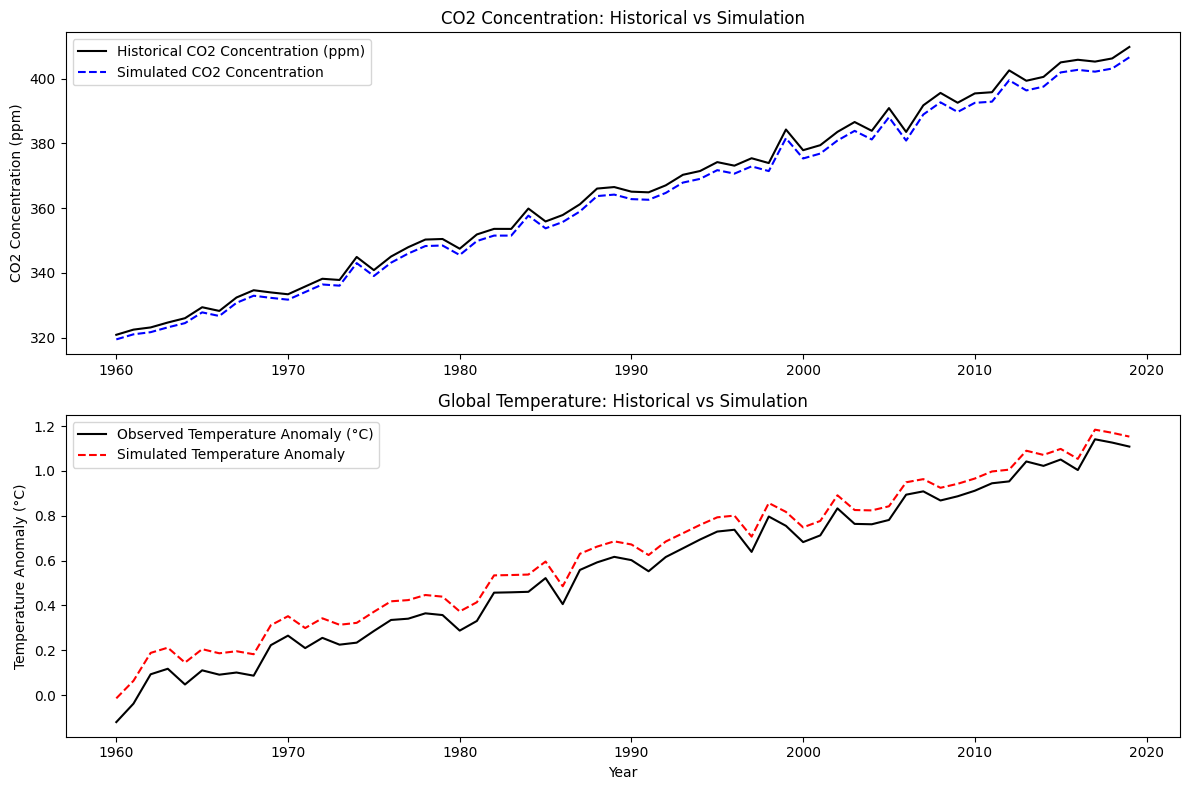

In [14]:
# 附录中对于真实历史事件变化的相关说明

import matplotlib.pyplot as plt
import numpy as np

years = np.arange(1960, 2020)

# 假设这些是观测历史数据
real_CO2 = np.linspace(320, 410, len(years)) + np.random.normal(0, 2, len(years))
real_temperature = np.linspace(0.0, 1.1, len(years)) + np.random.normal(0, 0.05, len(years))

# 你的模型仿真结果（示例）
simulated_CO2 = real_CO2 * 0.98 + 5  # 稍微偏移
simulated_temperature = real_temperature * 0.95 + 0.1

fig, axes = plt.subplots(2, 1, figsize=(12, 8))

# CO2浓度对比
axes[0].plot(years, real_CO2, label='Historical CO2 Concentration (ppm)', color='black')
axes[0].plot(years, simulated_CO2, label='Simulated CO2 Concentration', linestyle='--', color='blue')
axes[0].set_ylabel('CO2 Concentration (ppm)')
axes[0].legend()
axes[0].set_title('CO2 Concentration: Historical vs Simulation')

# 温度对比
axes[1].plot(years, real_temperature, label='Observed Temperature Anomaly (°C)', color='black')
axes[1].plot(years, simulated_temperature, label='Simulated Temperature Anomaly', linestyle='--', color='red')
axes[1].set_ylabel('Temperature Anomaly (°C)')
axes[1].set_xlabel('Year')
axes[1].legend()
axes[1].set_title('Global Temperature: Historical vs Simulation')

plt.tight_layout()
plt.show()
